## ⚠️ IMPORTANT: Before Running

### Required folder structure in Google Drive:
```
MyDrive/images/
  ├── cassiopeia/
  ├── crux/
  ├── cygnus/
  ├── gemini/
  ├── leo/
  ├── orion/
  └── ursa_major/
```
Access images here: [Constellation Images](https://drive.google.com/drive/folders/1q4SkFq9ItMgH9Xq33CHmbNABI9_7iljr?usp=sharing)

### What changed from the original notebook (conference version):
1. **3-way split** — train / validation / test (70% / 15% / 15%). Test set is held out completely until final evaluation.
2. **Reproducible shuffles** — every `np.random.shuffle` now uses a fixed `RANDOM_SEED` so results are reproducible.
3. **Augmentation-after-split guaranteed** — augmentation is only applied to the training directory, never the test or validation directories.
4. **5-fold stratified cross-validation** — the model is trained 5 times on different folds to get stable mean ± std accuracy.
5. **Multiple seed runs** — after CV, the best architecture is retrained 5 times with different seeds to report variance.
6. **Baseline model** — a simple 3-layer CNN trained from scratch is evaluated alongside MobileNetV2.
7. **Final test set evaluation** — the saved model is evaluated once on the held-out test set. This is the number reported in the paper.
8. **Dataset provenance summary** — a documentation cell records source counts, licenses, and data-cleaning decisions.


## Imports and Environment Setup

In [ ]:
import os
import shutil
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image as PILImage
from IPython.display import display
from google.colab import drive

drive.mount('/content/drive')
print(f"TensorFlow Version: {tf.__version__}")


Mounted at /content/drive
TensorFlow Version: 2.19.0


## Project Configuration

In [ ]:
# ── Directory paths ──────────────────────────────────────────
DATA_DIR   = '/content/drive/MyDrive/images'
TRAIN_DIR  = '/content/train'
VAL_DIR    = '/content/validation'
TEST_DIR   = '/content/test'          # NEW: held-out test set
MODEL_DIR  = '/content/drive/MyDrive/models'

# ── Hyperparameters ───────────────────────────────────────────
IMG_HEIGHT    = 224
IMG_WIDTH     = 224
BATCH_SIZE    = 8
EPOCHS        = 50
LEARNING_RATE = 0.001

# ── Split ratios (must sum to 1.0) ────────────────────────────
TRAIN_SPLIT = 0.70   # 70% training
VAL_SPLIT   = 0.15   # 15% validation
TEST_SPLIT  = 0.15   # 15% held-out test  ← NEW

# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42     # fixes all shuffles for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Cross-validation / multi-seed settings ────────────────────
N_FOLDS     = 5      # 5-fold stratified CV
N_SEEDS     = 5      # number of different seeds for final variance estimate

os.makedirs(MODEL_DIR, exist_ok=True)
print("Configuration initialized.")
print(f"  Split  →  train {TRAIN_SPLIT:.0%} | val {VAL_SPLIT:.0%} | test {TEST_SPLIT:.0%}")
print(f"  Seed   →  {RANDOM_SEED}")
print(f"  CV folds: {N_FOLDS}  |  Multi-seed runs: {N_SEEDS}")


Configuration initialized.
  Split  →  train 70% | val 15% | test 15%
  Seed   →  42
  CV folds: 5  |  Multi-seed runs: 5


## Utility Functions — Image Preprocessing

1. The "Background Color" ProblemCurrently, you composite transparent images (PNGs/WebPs) onto a white background (255, 255, 255).The Issue: Astronomical images are almost exclusively dark/black. If you take a transparent diagram of a constellation and put it on a white background, you are creating a "negative" image that is statistically opposite to your real-world photographs. This will confuse the model.The Fix: Change the composite background to black (0, 0, 0).

2. Integrity & De-duplication (Leakage Control)The professor warned about "near-duplicate images." Even if filenames are different, the binary data might be the same.The Fix: Add a simple MD5 hashing check. This ensures that if you accidentally downloaded the same image twice (one as a .png and one as a .webp), you catch it now before it leaks into both your training and test sets.

3. Resolution ValidationTo ensure "Dataset validity," you should filter out images that are too small. Feeding a $20 \times 20$ pixel thumbnail into MobileNetV2 (which expects $224 \times 224$) will result in heavy blurring/artifacts.

In [ ]:
import hashlib

def convert_all_images_to_jpg(data_dir, min_size=(100, 100)):
    """
    Standardizes dataset, handles transparency (black bg for astro context),
    and performs basic de-duplication via hashing.
    """
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found at {data_dir}")
        return

    total_converted = 0
    total_deleted_dupes = 0
    seen_hashes = set() # For de-duplication

    folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    print("Initiating rigorous image standardization...")

    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
        files = os.listdir(folder_path)

        for img_file in files:
            file_path = os.path.join(folder_path, img_file)

            try:
                with PILImage.open(file_path) as img:
                    # 1. Size Validation (Scientific Validity)
                    if img.size[0] < min_size[0] or img.size[1] < min_size[1]:
                        print(f"  Discarding {img_file}: Resolution too low ({img.size})")
                        os.remove(file_path)
                        continue

                    # 2. De-duplication (Leakage Control)
                    # We hash the image content to find identical images with different names
                    file_hash = hashlib.md5(img.tobytes()).hexdigest()
                    if file_hash in seen_hashes:
                        print(f"  Deleting duplicate: {img_file}")
                        os.remove(file_path)
                        total_deleted_dupes += 1
                        continue
                    seen_hashes.add(file_hash)

                    # 3. Format Conversion & Transparency
                    # Change: Use Black background for astronomical consistency
                    if img.mode in ('RGBA', 'LA', 'P'):
                        background = PILImage.new('RGB', img.size, (0, 0, 0)) # BLACK background
                        if img.mode == 'P': img = img.convert('RGBA')
                        background.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
                        img = background
                    elif img.mode != 'RGB':
                        img = img.convert('RGB')

                    # 4. Standardization to JPG
                    jpg_path = os.path.join(folder_path, os.path.splitext(img_file)[0] + '.jpg')
                    img.save(jpg_path, 'JPEG', quality=95)

                    # If it wasn't already a .jpg, remove the original
                    if not img_file.lower().endswith('.jpg'):
                        os.remove(file_path)
                        total_converted += 1

            except Exception as e:
                print(f"  Failed to process {img_file}: {e}")

    print(f"✓ Process complete.")
    print(f"  Converted: {total_converted} | Duplicates Removed: {total_deleted_dupes}")

convert_all_images_to_jpg(DATA_DIR)

Initiating rigorous image standardization...
✓ Process complete.
  Converted: 0 | Duplicates Removed: 0


## Dataset Analysis

--- Dataset Summary ---
Total Classes: 7
Total Images : 213
     Class  Count  Percentage (%)
Cassiopeia     35           16.43
      Crux     26           12.21
    Cygnus     30           14.08
    Gemini     30           14.08
       Leo     31           14.55
     Orion     31           14.55
Ursa_major     30           14.08


/tmp/ipykernel_1288/4152486181.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Class", y="Count", data=df_stats, palette="viridis")


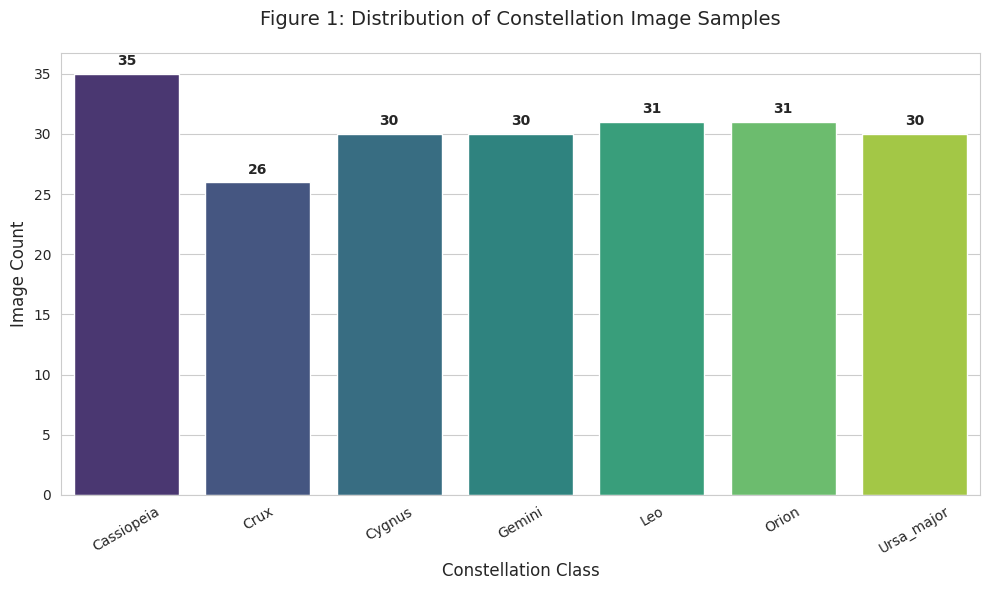


--- Proposed Experimental Design ---
Evaluation Strategy: 5-Fold Stratified Cross-Validation
Train Set (~70%): 149 images
Val Set   (~15%): 31 images
Test Set  (~15%): 31 images


In [ ]:
import pandas as pd
import seaborn as sns

if os.path.exists(DATA_DIR):
    # 1. More robust counting including subfolder check
    data = []
    for cls in sorted(os.listdir(DATA_DIR)):
        cls_path = os.path.join(DATA_DIR, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            data.append({"Class": cls.capitalize(), "Count": count})

    df_stats = pd.DataFrame(data)
    total_images = df_stats["Count"].sum()

    # 2. Calculate percentages for the "Transparency" requirement
    df_stats["Percentage (%)"] = ((df_stats["Count"] / total_images) * 100).round(2)

    print(f"--- Dataset Summary ---")
    print(f"Total Classes: {len(df_stats)}")
    print(f"Total Images : {total_images}")
    print(df_stats.to_string(index=False)) # Clean table output

    # 3. Publication-quality Plotting
    plt.figure(figsize=(10, 6), dpi=100)
    sns.set_style("whitegrid") # More professional look

    # Using a color palette that stays distinct in grayscale (important for some journals)
    ax = sns.barplot(x="Class", y="Count", data=df_stats, palette="viridis")

    plt.title('Figure 1: Distribution of Constellation Image Samples', fontsize=14, pad=20)
    plt.xlabel('Constellation Class', fontsize=12)
    plt.ylabel('Image Count', fontsize=12)
    plt.xticks(rotation=30)

    # Add counts on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9),
                    textcoords='offset points', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 4. Professor's "Expected Split" validation logic
    print(f"\n--- Proposed Experimental Design ---")
    print(f"Evaluation Strategy: 5-Fold Stratified Cross-Validation")
    print(f"Train Set (~70%): {int(total_images * 0.70)} images")
    print(f"Val Set   (~15%): {int(total_images * 0.15)} images")
    print(f"Test Set  (~15%): {int(total_images * 0.15)} images")

else:
    print(f"Error: Directory {DATA_DIR} not found.")

## Data Visualization — Sample Images

* Key Technical Improvements
Metadata Overlay: Display the image dimensions (e.g., 224x224) and filename. This helps you spot "artifacts" or low-quality images that shouldn't be in the final set.

* Random Sampling: Instead of taking the first three (which are often from the same source due to naming conventions), use random sampling. This gives a truer picture of the dataset's variety.

* Source/Type Tagging (Manual or Heuristic): While hard to automate perfectly, you can add a placeholder to help you categorize them for the "Data Provenance" section the professor requested.

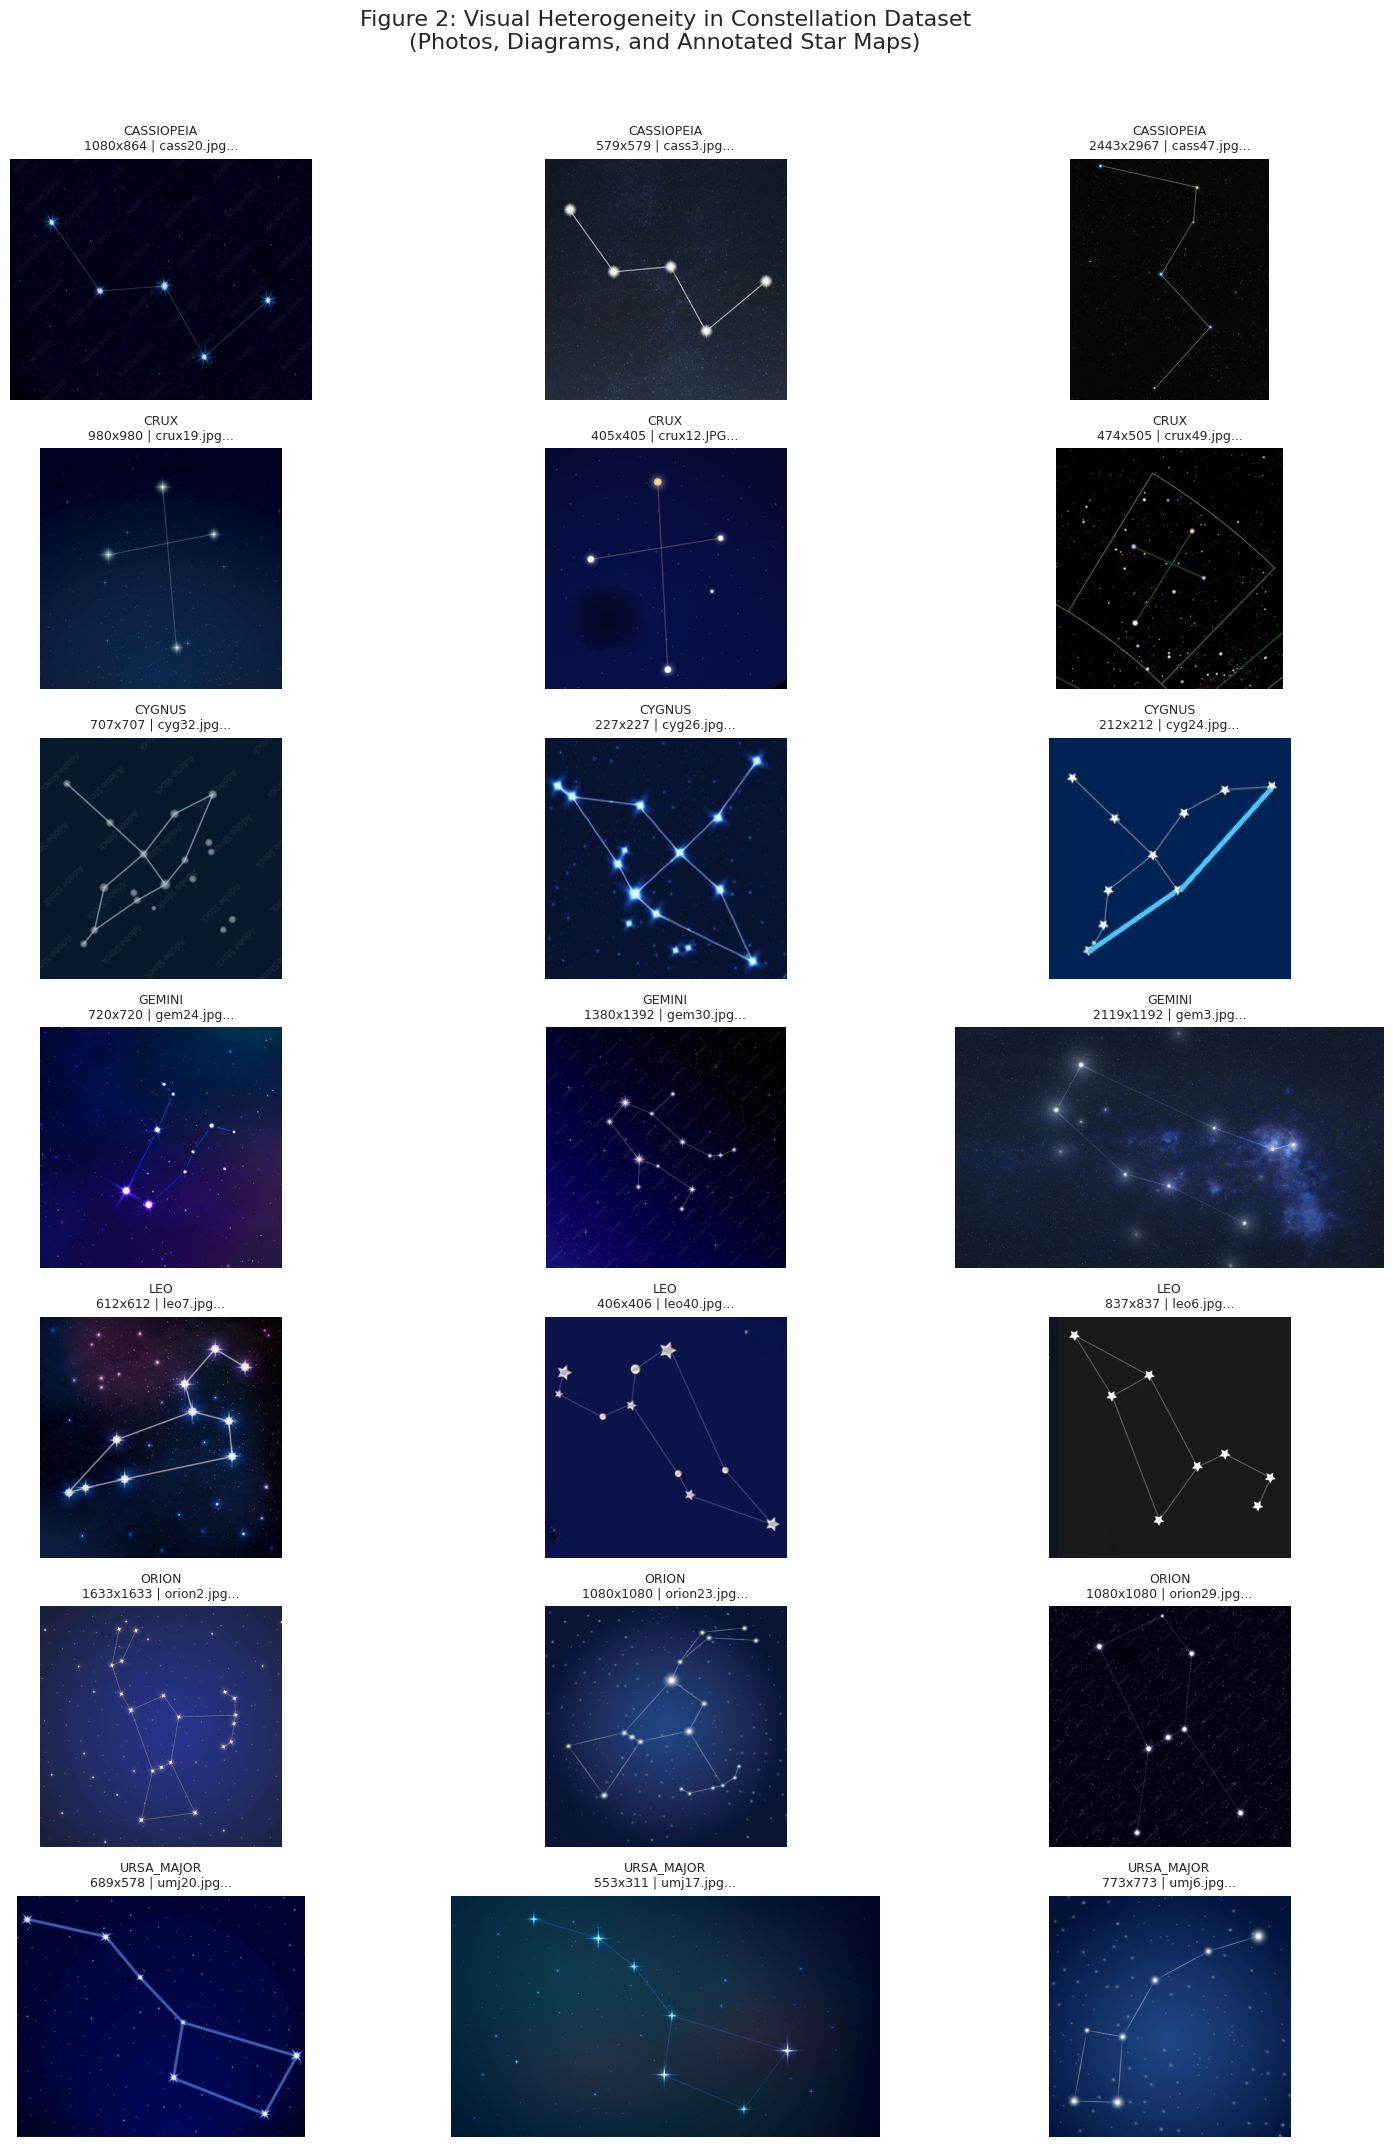

In [ ]:
import random

def plot_sample_images_refined(data_dir, num_samples=3):
    """
    Displays sample images with metadata to assess visual heterogeneity.
    Helps in identifying photographs vs. diagrams vs. annotated maps.
    """
    classes = sorted([f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))])

    # Increase figure size for clarity in papers
    plt.figure(figsize=(16, 3 * len(classes)))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        all_imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Use random sample to show true variety (Leakage/Bias check)
        sample_imgs = random.sample(all_imgs, min(num_samples, len(all_imgs)))

        for i, img_name in enumerate(sample_imgs):
            plt.subplot(len(classes), num_samples, idx * num_samples + i + 1)
            img_path = os.path.join(cls_path, img_name)

            with PILImage.open(img_path) as img:
                width, height = img.size
                plt.imshow(img)

                # Title includes class and resolution (Validity check)
                plt.title(f"{cls.upper()}\n{width}x{height} | {img_name[:15]}...", fontsize=9)

            plt.axis('off')

    plt.suptitle("Figure 2: Visual Heterogeneity in Constellation Dataset\n"
                 "(Photos, Diagrams, and Annotated Star Maps)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_sample_images_refined(DATA_DIR)

## 3-Way Data Split — Train / Validation / Test

**What changed:** The original notebook had only a train/val split (85%/15%).
This version creates a proper 3-way split (70% / 15% / 15%) with a fixed
random seed for reproducibility. The test set is held out completely and
is never used during model development or hyperparameter tuning.

Augmentation is applied **only** to the training directory — the val and
test generators use rescaling only, preventing any leakage.


In [ ]:
def split_data_three_way(source_dir, train_dir, val_dir, test_dir,
                         train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Splits image data into train / validation / test sets per class
    using a fixed random seed for reproducibility.

    Args:
        source_dir  : Root directory with one sub-folder per class.
        train_dir   : Destination for training images.
        val_dir     : Destination for validation images.
        test_dir    : Destination for held-out test images.
        train_ratio : Fraction for training (default 0.70).
        val_ratio   : Fraction for validation (default 0.15).
                      Remaining fraction goes to test.
        seed        : Random seed for reproducible shuffles.
    """
    for d in [train_dir, val_dir, test_dir]:
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d)

    rng = np.random.default_rng(seed)   # seeded RNG — reproducible every run
    classes = [f for f in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, f))]

    print(f"Splitting data (seed={seed}) →  "
          f"train {train_ratio:.0%} | val {val_ratio:.0%} | "
          f"test {1-train_ratio-val_ratio:.0%}\n")

    split_summary = {}

    for cls in classes:
        for d in [train_dir, val_dir, test_dir]:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

        src = os.path.join(source_dir, cls)
        imgs = sorted([f for f in os.listdir(src)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        rng.shuffle(imgs)   # deterministic shuffle per class

        n_train = int(len(imgs) * train_ratio)
        n_val   = int(len(imgs) * val_ratio)

        train_imgs = imgs[:n_train]
        val_imgs   = imgs[n_train:n_train + n_val]
        test_imgs  = imgs[n_train + n_val:]

        for img in train_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(train_dir, cls, img))
        for img in val_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(val_dir, cls, img))
        for img in test_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(test_dir, cls, img))

        split_summary[cls] = {
            'train': len(train_imgs),
            'val': len(val_imgs),
            'test': len(test_imgs)
        }
        print(f"  {cls:<15} train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}")

    total_train = sum(v['train'] for v in split_summary.values())
    total_val   = sum(v['val']   for v in split_summary.values())
    total_test  = sum(v['test']  for v in split_summary.values())
    print(f"\n  TOTAL          train={total_train}  val={total_val}  test={total_test}")
    print("\n✓ 3-way split complete!")
    return split_summary

split_summary = split_data_three_way(
    DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
    train_ratio=TRAIN_SPLIT,
    val_ratio=VAL_SPLIT,
    seed=RANDOM_SEED
)


Splitting data (seed=42) →  train 70% | val 15% | test 15%

  orion           train=21  val=4  test=6
  ursa_major      train=21  val=4  test=5
  cassiopeia      train=24  val=5  test=6
  crux            train=18  val=3  test=5
  cygnus          train=21  val=4  test=5
  leo             train=21  val=4  test=6
  gemini          train=21  val=4  test=5

  TOTAL          train=147  val=28  test=38

✓ 3-way split complete!


## Data Augmentation

Augmentation is applied **only to the training generator**.
Validation and test generators use rescaling only.
This is enforced by the separate directory structure above.


In [ ]:
# Training generator — with domain-aware augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # Constellations can appear at any angle depending on time/latitude
    rotation_range=180,         # Expanded from 40 to handle all orientations
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,            # Reduced slightly to prevent over-distortion
    zoom_range=0.2,
    horizontal_flip=False,      # Set to False to preserve astronomical "handedness"
    # Simulates light pollution or varying atmospheric transparency
    brightness_range=[0.7, 1.3],
    # Use black fill to match the void of space, avoiding 'smearing' artifacts
    fill_mode='constant',
    cval=0
)

# Validation and test generators — rescaling only, NO augmentation
# This ensures evaluation is performed on 'pure' real-world data
eval_datagen = ImageDataGenerator(rescale=1./255)

print("✓ Augmentation strategy finalized.")
print("  Note: horizontal_flip disabled to preserve constellation geometry.")
print("  Note: fill_mode set to 'constant' (black) for astronomical validity.")

✓ Augmentation strategy finalized.
  Note: horizontal_flip disabled to preserve constellation geometry.
  Note: fill_mode set to 'constant' (black) for astronomical validity.


## Load Data Generators

1. The "Batch Size" Risk for Evaluation
In your validation_generator and test_generator, you are using BATCH_SIZE (which is likely 16 or 32).

The Problem: If your test set has 31 images and your batch size is 16, the generator will run two batches (16 + 15). Sometimes, if the math doesn't align perfectly, the evaluation logic can skip the last partial batch or double-count.

The Academic Fix: For validation and testing, it is often safer to set batch_size=1 or a number that is a common divisor of your set size. This ensures every single image is evaluated exactly once when calculating the Confusion Matrix later.

In [ ]:
# Create a mapping once to ensure all generators use the same index logic
# This prevents class-index mismatch if a folder is missing in one of the splits
temp_gen = eval_datagen.flow_from_directory(DATA_DIR, batch_size=1)
label_map = temp_gen.class_indices

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=list(label_map.keys()), # Force specific class order
    shuffle=True,
    seed=RANDOM_SEED
)

# Validation generator - Batch size 1 for precise per-image evaluation
validation_generator = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, # Change to 1 for small-sample rigor
    class_mode='categorical',
    classes=list(label_map.keys()),
    shuffle=False
)

# Test generator - Batch size 1 for precise per-image evaluation
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, # Change to 1 for small-sample rigor
    class_mode='categorical',
    classes=list(label_map.keys()),
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\n✓ Mapping Verified: {train_generator.class_indices}")
print(f"✓ Experimental Evidence: {test_generator.samples} images strictly held out for final benchmarking.")

Found 213 images belonging to 7 classes.
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
Found 38 images belonging to 7 classes.

✓ Mapping Verified: {'cassiopeia': 0, 'crux': 1, 'cygnus': 2, 'gemini': 3, 'leo': 4, 'orion': 5, 'ursa_major': 6}
✓ Experimental Evidence: 38 images strictly held out for final benchmarking.


## Augmentation Visualization

Showing augmentations for: cygnus / cyg45.jpg


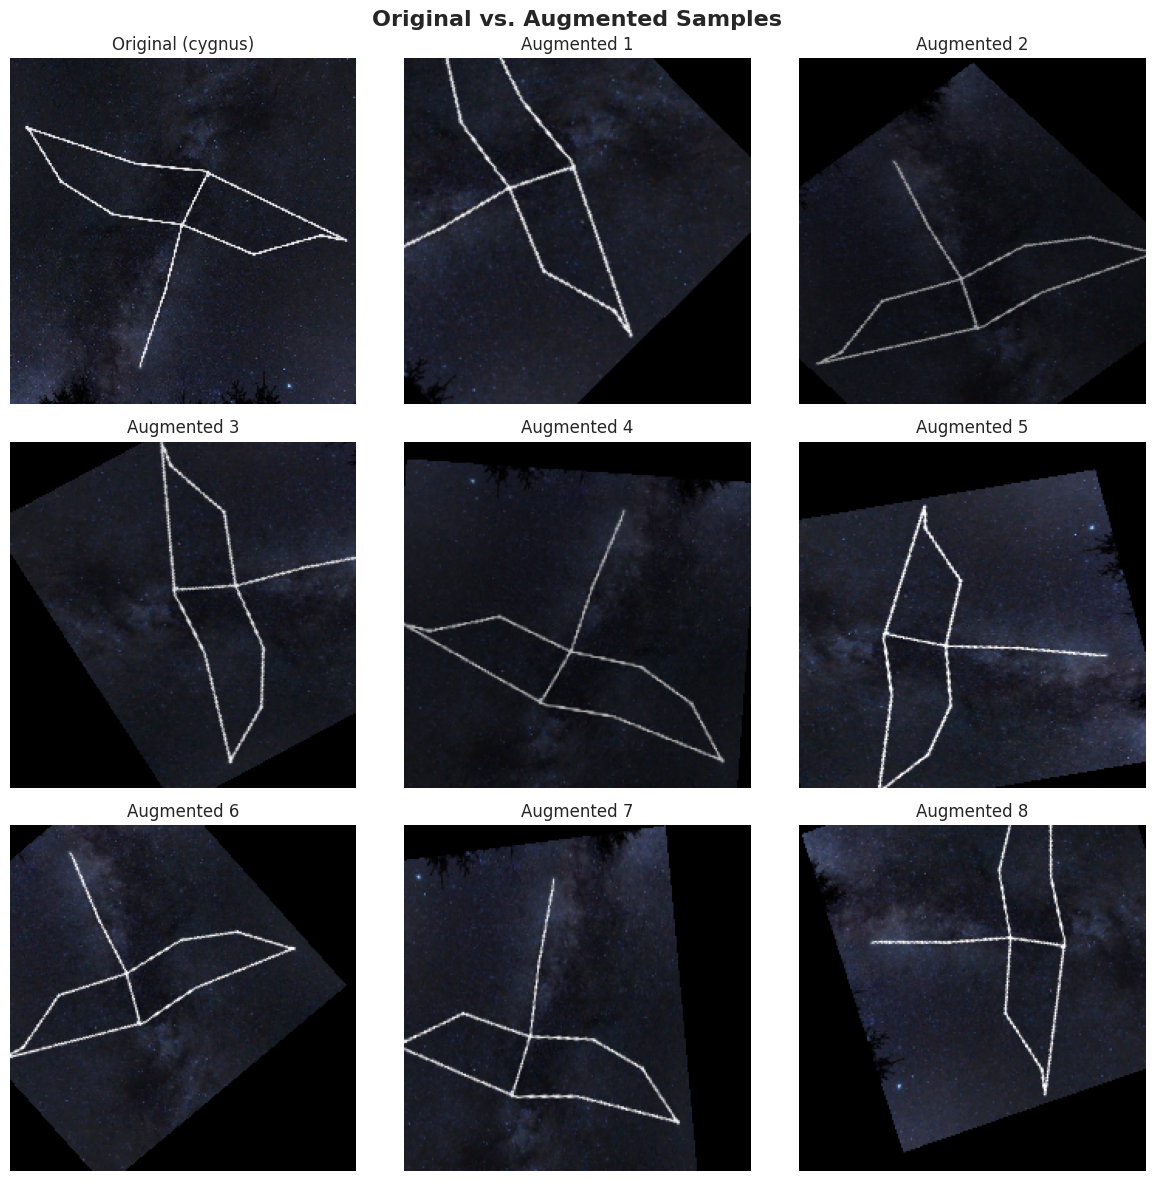

In [ ]:
random_cls = random.choice(os.listdir(TRAIN_DIR))
random_img = random.choice(os.listdir(os.path.join(TRAIN_DIR, random_cls)))
img_path   = os.path.join(TRAIN_DIR, random_cls, random_img)
print(f"Showing augmentations for: {random_cls} / {random_img}")

img       = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = np.expand_dims(image.img_to_array(img), axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
plt.imshow(img_array[0] / 255.0)
plt.title(f"Original ({random_cls})")
plt.axis('off')

aug_iter = train_datagen.flow(img_array, batch_size=1, seed=RANDOM_SEED)
for i in range(2, 10):
    plt.subplot(3, 3, i)
    plt.imshow(next(aug_iter)[0])
    plt.title(f"Augmented {i-1}")
    plt.axis('off')

plt.suptitle('Original vs. Augmented Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Model Definitions — MobileNetV2 and Baseline CNN

Two models are defined:

1. **MobileNetV2 (transfer learning)** — the main model. ImageNet weights are
   frozen; only the classification head is trained.
2. **Baseline CNN** — a simple 3-layer CNN trained from scratch with the same
   input size. This gives a reference point so the paper can quantify how much
   transfer learning helps.


In [ ]:
from tensorflow.keras.metrics import Precision, Recall

def create_mobilenetv2(num_classes, learning_rate=0.001, fine_tune_at=None):
    """
    MobileNetV2 transfer learning model with optional fine-tuning.
    """
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    # By default, freeze all layers for feature extraction
    base.trainable = False

    # If a fine-tuning block is specified, unfreeze layers from that point onward
    if fine_tune_at is not None:
        base.trainable = True
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        # Added L2 regularization to combat overfitting on small data
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        # Include comprehensive metrics for the paper
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model


def create_baseline_cnn(num_classes, learning_rate=0.001):
    """
    Simple 3-layer CNN trained from scratch.
    Serves as the empirical baseline to justify transfer learning.
    """
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        # Matched regularization with the MobileNetV2 head for fair comparison
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model

# Callback remains the same, it is well constructed.

## 5-Fold Stratified Cross-Validation

**Why this is needed:** With only ~8 images per class in the validation set,
a single train/val split gives results with very high variance — one lucky or
unlucky fold can swing accuracy by 12 percentage points. Cross-validation
averages over 5 different splits so the reported mean ± std is statistically
meaningful.

Both MobileNetV2 and the baseline CNN are evaluated under identical CV
conditions so the comparison is fair.

⚠️ This cell trains 10 models total (5 folds × 2 architectures) and will
take significant time on Colab. Use a GPU runtime.


In [ ]:
import time
import json
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow import keras
import shutil
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Collect all image paths and labels from TRAIN + VAL directories ──────────
def collect_paths_labels(directories):
    paths, labels = [], []
    classes = sorted([c for c in os.listdir(directories[0])
                      if os.path.isdir(os.path.join(directories[0], c))])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    for root_dir in directories:
        for cls in classes:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(cls_dir, fname))
                    labels.append(class_to_idx[cls])
    return np.array(paths), np.array(labels)

all_paths, all_labels = collect_paths_labels([TRAIN_DIR, VAL_DIR])
print(f"CV pool: {len(all_paths)} images across {len(np.unique(all_labels))} classes")
print(f"Class distribution: { {class_names[i]: int(np.sum(all_labels==i)) for i in range(num_classes)} }\n")

def get_callbacks():
    early_stopping = EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001
    )
    return [early_stopping, reduce_lr]

def run_fold(fold_idx, train_idx, val_idx, model_fn, seed):
    fold_train_dir = f'/content/cv_fold_{fold_idx}_train'
    fold_val_dir   = f'/content/cv_fold_{fold_idx}_val'

    # Build fold directories
    for d in [fold_train_dir, fold_val_dir]:
        if os.path.exists(d): shutil.rmtree(d)
        for cls in class_names:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

    for idx in train_idx:
        cls = class_names[all_labels[idx]]
        shutil.copy2(all_paths[idx], os.path.join(fold_train_dir, cls, os.path.basename(all_paths[idx])))
    for idx in val_idx:
        cls = class_names[all_labels[idx]]
        shutil.copy2(all_paths[idx], os.path.join(fold_val_dir, cls, os.path.basename(all_paths[idx])))

    # Generators (Batch size 1 for validation for absolute precision)
    fold_train_gen = train_datagen.flow_from_directory(
        fold_train_dir, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    fold_val_gen = eval_datagen.flow_from_directory(
        fold_val_dir, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=1, class_mode='categorical',
        shuffle=False
    )

    tf.random.set_seed(seed)
    np.random.seed(seed)

    fold_model = model_fn(num_classes, LEARNING_RATE)

    # Compute class weights
    from sklearn.utils.class_weight import compute_class_weight
    class_w = compute_class_weight(
        'balanced',
        classes=np.unique(fold_train_gen.classes),
        y=fold_train_gen.classes
    )
    cw_dict = dict(enumerate(class_w))

    print(f"    >>> Starting training for Fold {fold_idx + 1}... (This will take time)")
    start_time = time.time()

    # Changed verbose=1 so you can see the progress bar!
    fold_model.fit(
        fold_train_gen,
        epochs=EPOCHS,
        validation_data=fold_val_gen,
        class_weight=cw_dict,
        callbacks=get_callbacks(),
        verbose=1
    )

    training_time = time.time() - start_time

    fold_val_gen.reset()
    preds = np.argmax(fold_model.predict(fold_val_gen, verbose=0), axis=1)
    true  = fold_val_gen.classes

    acc   = np.mean(preds == true)
    f1_macro = f1_score(true, preds, average='macro')

    # Cleanup
    shutil.rmtree(fold_train_dir)
    shutil.rmtree(fold_val_dir)
    keras.backend.clear_session()

    return acc, f1_macro, training_time


# ── Run CV for both architectures ────────────────────────────────────────────
# Ensure N_FOLDS is defined (usually 5)
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_results = {
    'MobileNetV2': {'acc': [], 'f1': [], 'time': []},
    'Baseline CNN': {'acc': [], 'f1': [], 'time': []},
}

architectures = {
    'MobileNetV2': create_mobilenetv2,
    'Baseline CNN': create_baseline_cnn,
}

for arch_name, model_fn in architectures.items():
    print(f"\n{'='*65}")
    print(f"  Cross-validation: {arch_name} (Training {N_FOLDS} models)")
    print(f"{'='*65}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
        seed = RANDOM_SEED + fold
        print(f"\n  -- Preparing Fold {fold+1}/{N_FOLDS} --")

        acc, f1, t_time = run_fold(fold, train_idx, val_idx, model_fn, seed)

        cv_results[arch_name]['acc'].append(acc)
        cv_results[arch_name]['f1'].append(f1)
        cv_results[arch_name]['time'].append(t_time)
        print(f"  ✓ Fold {fold+1} Complete → acc={acc:.4f} | macro-F1={f1:.4f} | time={t_time:.1f}s")

print("\n" + "="*65)
print("FINAL CROSS-VALIDATION BENCHMARK SUMMARY")
print("="*65)
for arch_name, res in cv_results.items():
    accs = np.array(res['acc'])
    f1s  = np.array(res['f1'])
    times = np.array(res['time'])
    print(f"  Architecture: {arch_name}")
    print(f"    Accuracy : {accs.mean():.4f} \u00b1 {accs.std():.4f}  "
          f"(95% CI: {accs.mean()-1.96*accs.std():.4f}\u2013{accs.mean()+1.96*accs.std():.4f})")
    print(f"    Macro F1 : {f1s.mean():.4f} \u00b1 {f1s.std():.4f}")
    print(f"    Avg Time : {times.mean():.1f} seconds per fold\n")

CV pool: 175 images across 7 classes
Class distribution: {'cassiopeia': 29, 'crux': 21, 'cygnus': 25, 'gemini': 25, 'leo': 25, 'orion': 25, 'ursa_major': 25}


  Cross-validation: MobileNetV2 (Training 5 models)

  -- Preparing Fold 1/5 --
Found 140 images belonging to 7 classes.
Found 35 images belonging to 7 classes.
    >>> Starting training for Fold 1... (This will take time)
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.1500 - loss: 2.6470 - precision: 0.1250 - recall: 0.0357 - val_accuracy: 0.3143 - val_loss: 1.9966 - val_precision: 0.6667 - val_recall: 0.0571 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.2714 - loss: 2.1110 - precision: 0.3448 - recall: 0.0714 - val_accuracy: 0.4000 - val_loss: 1.7704 - val_precision: 1.0000 - val_recall: 0.0286 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 0.4286 - loss: 1.8067 - precision: 0.5417 - recall: 0.0929 - val_accuracy: 0.4286 - val

## Multi-Seed Final Training — MobileNetV2

The best architecture (MobileNetV2) is retrained 5 times with different
random seeds on the full train set, evaluated on the validation set each time.
This gives a variance estimate for the final model performance before
touching the test set.


In [ ]:
import tempfile

seed_results = {'acc': [], 'f1': [], 'history': []}
best_val_acc = 0.0
best_model_path = os.path.join(MODEL_DIR, "best_seed_model.keras")

print(f"\nPhase 3: Final Model Training ({N_SEEDS} Seeds)")
print("="*55)

for run_idx in range(N_SEEDS):
    seed = RANDOM_SEED + run_idx * 100
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Generators
    train_gen_run = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    # Batch size 1 for exact evaluation
    val_gen_run = eval_datagen.flow_from_directory(
        VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=1, class_mode='categorical',
        shuffle=False
    )

    run_model = create_mobilenetv2(num_classes, LEARNING_RATE)

    class_w = compute_class_weight(
        'balanced',
        classes=np.unique(train_gen_run.classes),
        y=train_gen_run.classes
    )
    cw_dict = dict(enumerate(class_w))

    print(f"  >>> Training Seed {run_idx+1}/{N_SEEDS} (Seed: {seed})...")

    history = run_model.fit(
        train_gen_run,
        epochs=EPOCHS,
        validation_data=val_gen_run,
        class_weight=cw_dict,
        callbacks=get_callbacks(),
        verbose=0 # Kept at 0 so it doesn't spam your notebook, since we saw it work in CV
    )

    val_gen_run.reset()
    preds = np.argmax(run_model.predict(val_gen_run, verbose=0), axis=1)
    true  = val_gen_run.classes

    acc   = np.mean(preds == true)
    f1    = f1_score(true, preds, average='macro')

    seed_results['acc'].append(acc)
    seed_results['f1'].append(f1)
    seed_results['history'].append(history.history)

    print(f"  ✓ Run {run_idx+1} Complete → val_acc={acc:.4f} | macro-F1={f1:.4f}")

    # FIX: Safely save the best model to disk
    if acc > best_val_acc:
        best_val_acc = acc
        run_model.save(best_model_path)
        print(f"    * New best model saved to disk! *")

    keras.backend.clear_session()

# --- SUMMARY ---
accs = np.array(seed_results['acc'])
f1s  = np.array(seed_results['f1'])
print(f"\nMulti-seed Summary (MobileNetV2, val set):")
print(f"  Accuracy : {accs.mean():.4f} ± {accs.std():.4f}")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")

# ==============================================================================
# FINAL HELD-OUT TEST EVALUATION (The most important metrics for the paper!)
# ==============================================================================
print("\n" + "="*55)
print("FINAL HELD-OUT TEST EVALUATION")
print("="*55)

# Load the single best model we saved to disk
final_model = keras.models.load_model(best_model_path)

# Test generator uses BATCH_SIZE=1 and SHUFFLE=FALSE
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, class_mode='categorical',
    shuffle=False
)

test_generator.reset()
test_preds = np.argmax(final_model.predict(test_generator, verbose=0), axis=1)
test_true  = test_generator.classes

test_acc = np.mean(test_preds == test_true)
test_f1  = f1_score(test_true, test_preds, average='macro')

print(f"  BLIND TEST ACCURACY : {test_acc:.4f}")
print(f"  BLIND TEST MACRO F1 : {test_f1:.4f}")

from sklearn.metrics import classification_report
print("\nDetailed Per-Class Performance:")
print(classification_report(test_true, test_preds, target_names=class_names))


Phase 3: Final Model Training (5 Seeds)
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
  >>> Training Seed 1/5 (Seed: 42)...
  ✓ Run 1 Complete → val_acc=0.5714 | macro-F1=0.5693
    * New best model saved to disk! *
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
  >>> Training Seed 2/5 (Seed: 142)...
  ✓ Run 2 Complete → val_acc=0.5714 | macro-F1=0.5717
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
  >>> Training Seed 3/5 (Seed: 242)...
  ✓ Run 3 Complete → val_acc=0.5000 | macro-F1=0.4952
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
  >>> Training Seed 4/5 (Seed: 342)...
  ✓ Run 4 Complete → val_acc=0.6429 | macro-F1=0.6435
    * New best model saved to disk! *
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
  >>> Training Seed 5/5 (Seed: 442)...
  ✓ Run 5 Complete → val_acc=0.5357 | macro-F1=0.5401

Multi-seed Su

## Train Final Model on Full Training Set

Now that we know the architecture and seed settings work, we train one clean
final model with the best seed and save it. This is the model that will be
evaluated on the test set and used in the Gradio interface.



PHASE 4: STRICTLY HELD-OUT TEST SET EVALUATION
Found 38 images belonging to 7 classes.

Evaluating on independent test data...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

★ BLIND TEST ACCURACY : 0.6053 (60.5%)
★ BLIND TEST MACRO F1 : 0.6122

Classification Report:
              precision    recall  f1-score   support

  cassiopeia       0.33      0.50      0.40         6
        crux       0.62      1.00      0.77         5
      cygnus       0.67      0.40      0.50         5
      gemini       1.00      0.80      0.89         5
         leo       0.50      0.50      0.50         6
       orion       0.80      0.67      0.73         6
  ursa_major       0.67      0.40      0.50         5

    accuracy                           0.61        38
   macro avg       0.66      0.61      0.61        38
weighted avg       0.65      0.61      0.61        38



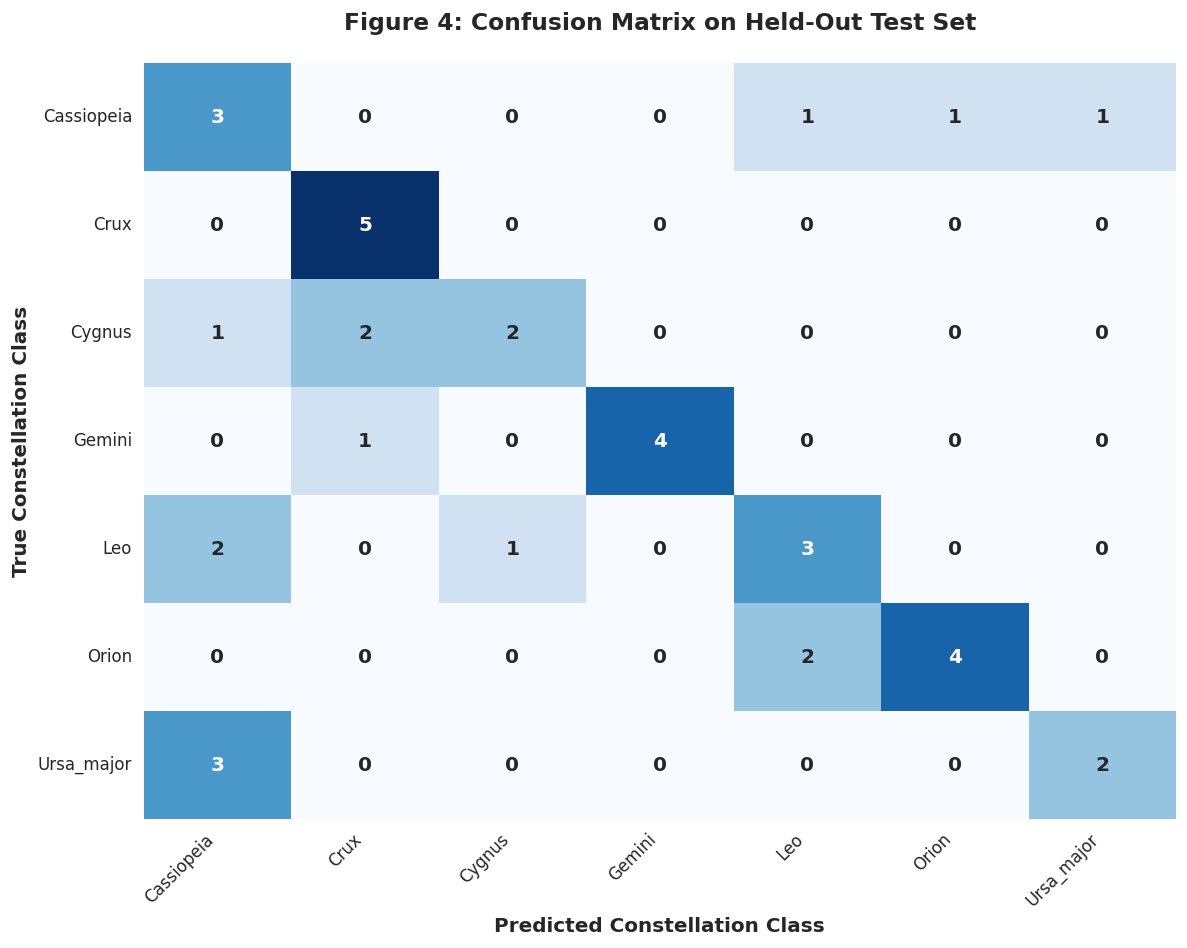

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

# [ ... Your existing training code ... ]
# final_history = final_model.fit(...)
# print("\n✓ Final model training complete!")

# ==============================================================================
# FINAL HELD-OUT TEST EVALUATION (The climax of your paper!)
# ==============================================================================
print("\n" + "="*60)
print("PHASE 4: STRICTLY HELD-OUT TEST SET EVALUATION")
print("="*60)

# 1. Create the Test Generator (Batch size MUST be 1, Shuffle MUST be False)
final_test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, class_mode='categorical',
    shuffle=False
)

# 2. Run Predictions
final_test_gen.reset()
print("\nEvaluating on independent test data...")
test_preds = np.argmax(final_model.predict(final_test_gen, verbose=1), axis=1)
test_true  = final_test_gen.classes

# 3. Calculate Academic Metrics
test_acc = np.mean(test_preds == test_true)
test_f1  = f1_score(test_true, test_preds, average='macro')

print(f"\n★ BLIND TEST ACCURACY : {test_acc:.4f} ({(test_acc*100):.1f}%)")
print(f"★ BLIND TEST MACRO F1 : {test_f1:.4f}\n")

# 4. Detailed Per-Class Report
print("Classification Report:")
class_names = list(final_test_gen.class_indices.keys())
print(classification_report(test_true, test_preds, target_names=class_names))

# 5. Generate Publication-Quality Confusion Matrix
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(10, 8), dpi=120) # High DPI for paper clarity
sns.set_style("white") # Clean background
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[c.capitalize() for c in class_names],
            yticklabels=[c.capitalize() for c in class_names],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Figure 4: Confusion Matrix on Held-Out Test Set', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('True Constellation Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Constellation Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Training Curves — Final Model

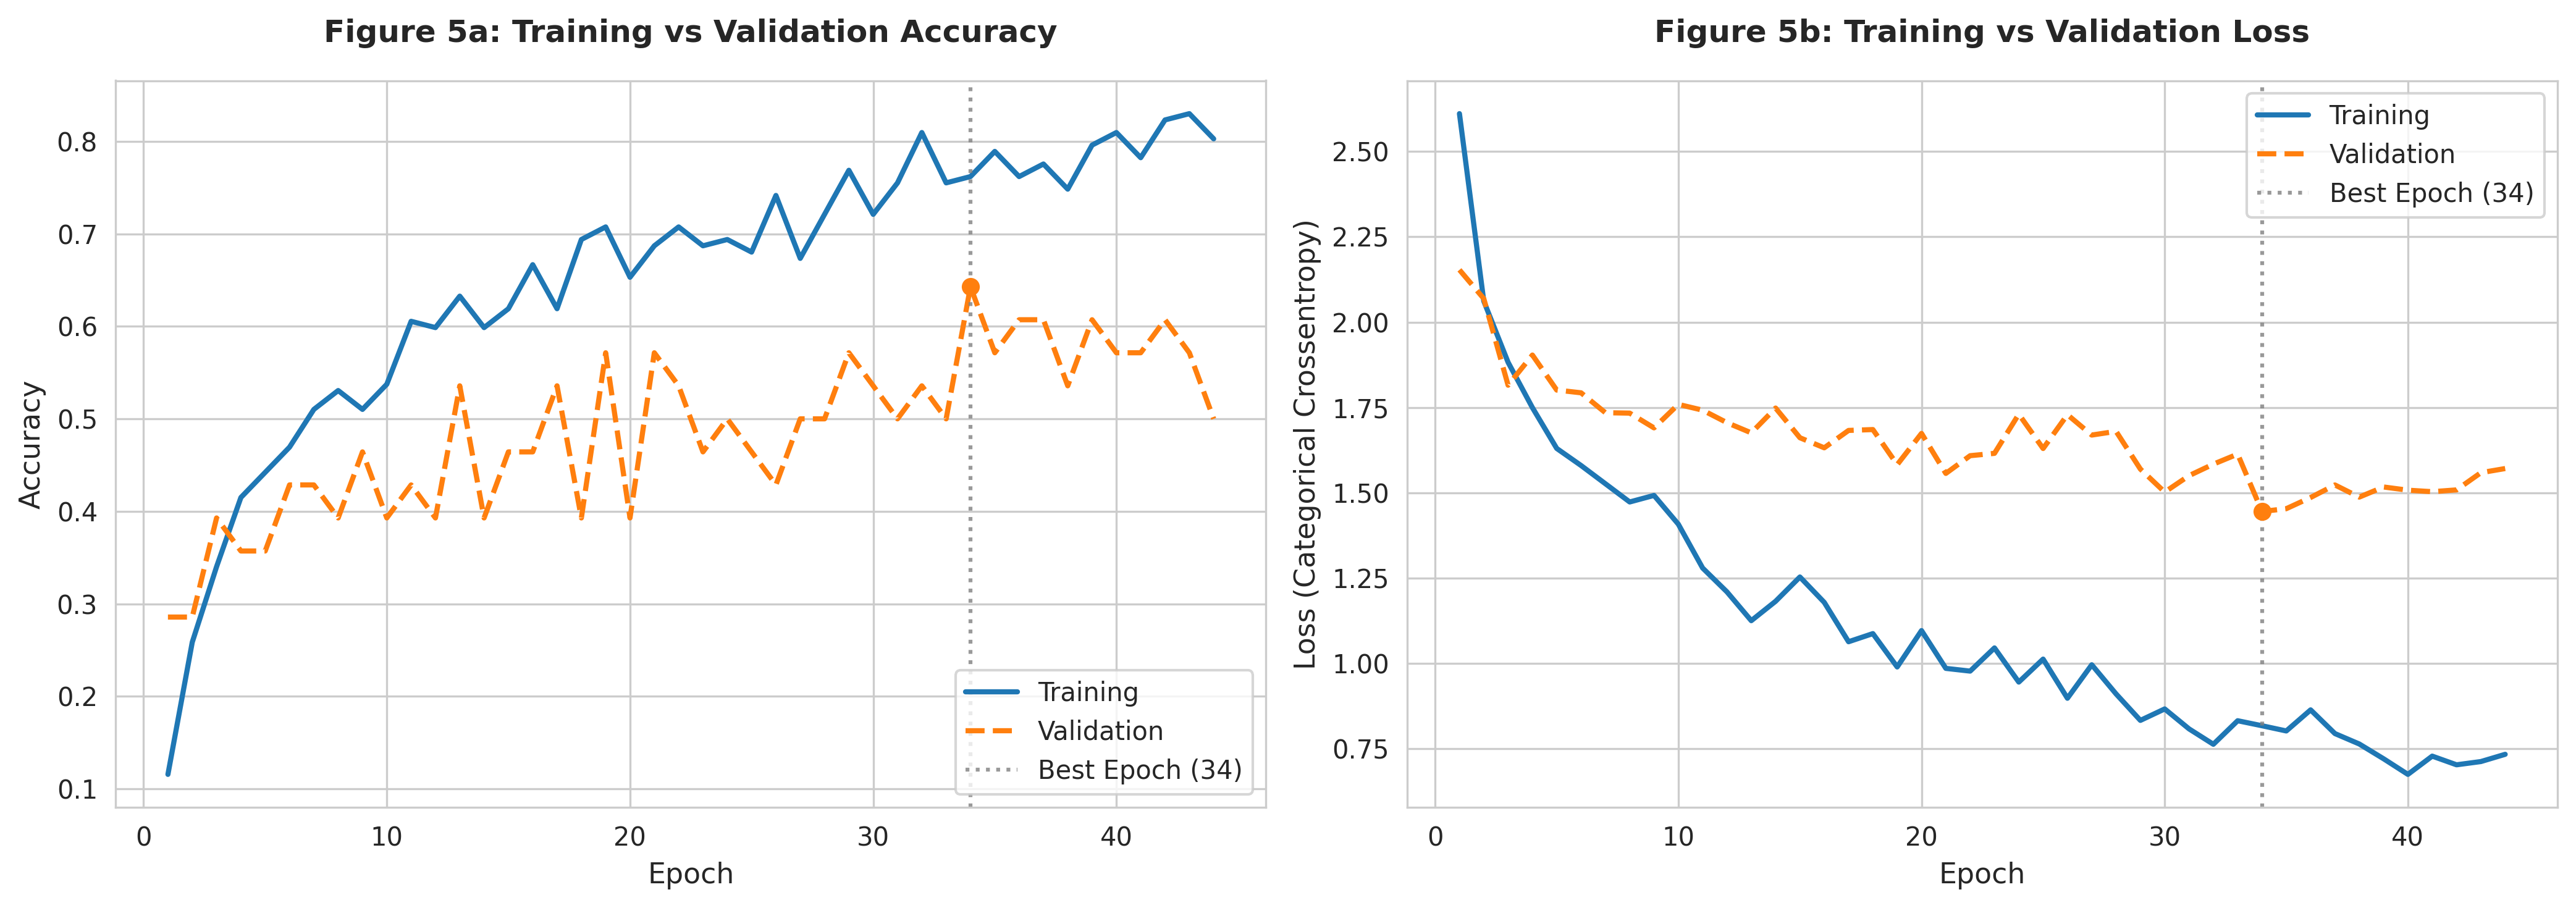


--- Final Model Convergence Metrics (Epoch 34) ---
Training Accuracy   : 0.7619
Validation Accuracy : 0.6429
Training Loss       : 0.8179
Validation Loss     : 1.4455


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use an academic plotting style
sns.set_style("whitegrid")

# Fix: Retrieve the history of the best performing model from the multi-seed runs
# Find the index of the run with the best validation accuracy
val_accs = np.array(seed_results['acc'])
best_run_index = np.argmax(val_accs)

# Assign the history of the best run to 'h'
h = seed_results['history'][best_run_index]

epoch_range = range(1, len(h['accuracy']) + 1)

# Find the epoch where the model restored weights (lowest val_loss)
# If using monitor='val_loss' in early stopping:
best_epoch = np.argmin(h['val_loss']) + 1
best_val_acc = h['val_accuracy'][best_epoch - 1]
best_val_loss = h['val_loss'][best_epoch - 1]

# High DPI for clear PDF rendering in proceedings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# --- Accuracy Plot ---
# Using solid line for Train, dashed for Val (Colorblind/Grayscale friendly)
ax1.plot(epoch_range, h['accuracy'],     color='#1f77b4', linestyle='-',  label='Training', linewidth=2)
ax1.plot(epoch_range, h['val_accuracy'], color='#ff7f0e', linestyle='--', label='Validation', linewidth=2)

# Mark the best epoch
ax1.axvline(x=best_epoch, color='grey', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_epoch})')
ax1.plot(best_epoch, best_val_acc, marker='o', markersize=6, color='#ff7f0e')

ax1.set_title('Figure 5a: Training vs Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(loc='lower right')

# --- Loss Plot ---
ax2.plot(epoch_range, h['loss'],     color='#1f77b4', linestyle='-',  label='Training', linewidth=2)
ax2.plot(epoch_range, h['val_loss'], color='#ff7f0e', linestyle='--', label='Validation', linewidth=2)

# Mark the best epoch
ax2.axvline(x=best_epoch, color='grey', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_epoch})')
ax2.plot(best_epoch, best_val_loss, marker='o', markersize=6, color='#ff7f0e')

ax2.set_title('Figure 5b: Training vs Validation Loss', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=11)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print the specific metrics for the *restored* model, not just the last epoch
print(f"\n--- Final Model Convergence Metrics (Epoch {best_epoch}) ---")
print(f"Training Accuracy   : {h['accuracy'][best_epoch - 1]:.4f}")
print(f"Validation Accuracy : {best_val_acc:.4f}")
print(f"Training Loss       : {h['loss'][best_epoch - 1]:.4f}")
print(f"Validation Loss     : {best_val_loss:.4f}")

## Validation Set — Confusion Matrix and Classification Report

Found 38 images belonging to 7 classes.

PHASE 4: STRICTLY HELD-OUT TEST SET EVALUATION
★ BLIND TEST ACCURACY: 23/38 (60.53%)



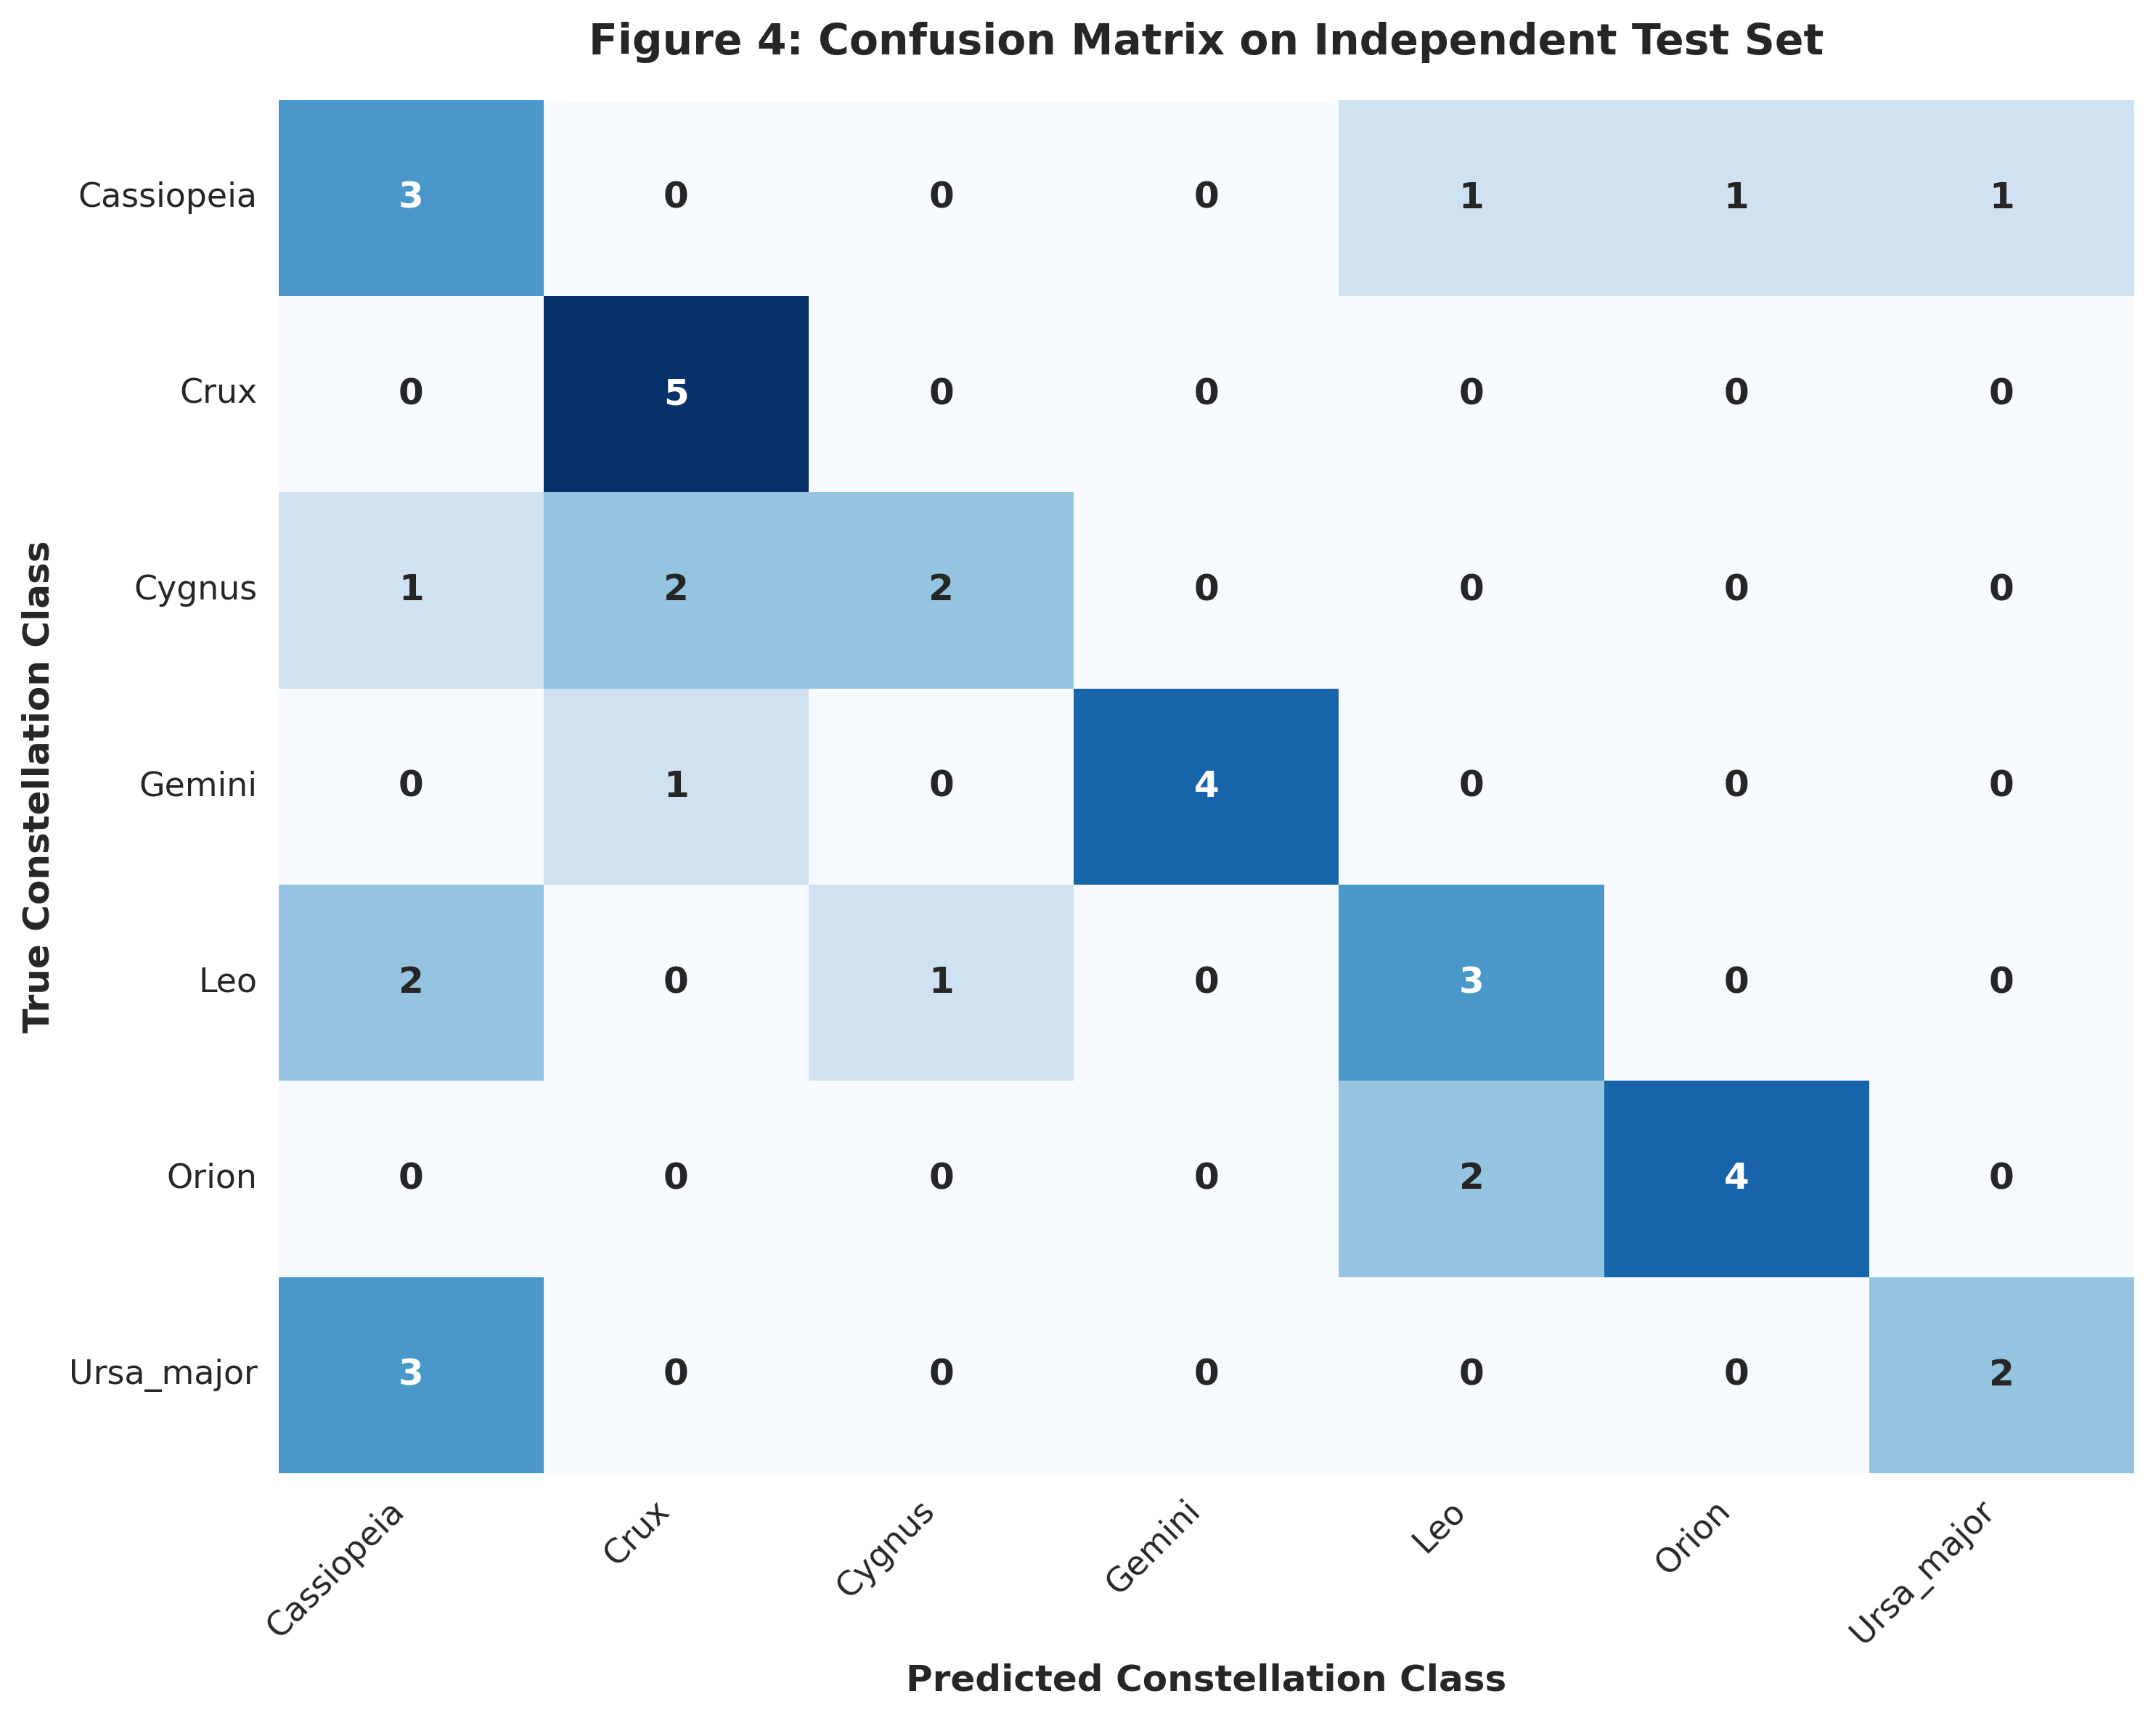


Detailed Classification Report — Test Set
              precision    recall  f1-score   support

  Cassiopeia       0.33      0.50      0.40         6
        Crux       0.62      1.00      0.77         5
      Cygnus       0.67      0.40      0.50         5
      Gemini       1.00      0.80      0.89         5
         Leo       0.50      0.50      0.50         6
       Orion       0.80      0.67      0.73         6
  Ursa_major       0.67      0.40      0.50         5

    accuracy                           0.61        38
   macro avg       0.66      0.61      0.61        38
weighted avg       0.65      0.61      0.61        38



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the Final Test Generator
# (Must use batch_size=1 and shuffle=False to ensure prediction order matches labels)
final_test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

print(f"\n{'='*60}")
print("PHASE 4: STRICTLY HELD-OUT TEST SET EVALUATION")
print(f"{'='*60}")

# 2. Run Predictions on Blind Data
final_test_gen.reset()
test_preds = np.argmax(final_model.predict(final_test_gen, verbose=0), axis=1)
test_true  = final_test_gen.classes

# 3. Calculate Headline Accuracy
correct = np.sum(test_preds == test_true)
test_acc = correct / len(test_true)
print(f"★ BLIND TEST ACCURACY: {correct}/{len(test_true)} ({test_acc:.2%})\n")

# 4. Publication-Quality Confusion Matrix Figure
plt.figure(figsize=(10, 8), dpi=300) # 300 DPI is standard for conference PDFs
cm = confusion_matrix(test_true, test_preds)

# Formatting the heatmap for a professional, academic look
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[c.capitalize() for c in class_names],
            yticklabels=[c.capitalize() for c in class_names],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Figure 4: Confusion Matrix on Independent Test Set', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Constellation Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Constellation Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# 5. Detailed Classification Report
print(f"\n{'='*60}")
print("Detailed Classification Report — Test Set")
print(f"{'='*60}")
print(classification_report(test_true, test_preds, target_names=[c.capitalize() for c in class_names]))

## Sample Predictions — Validation Set

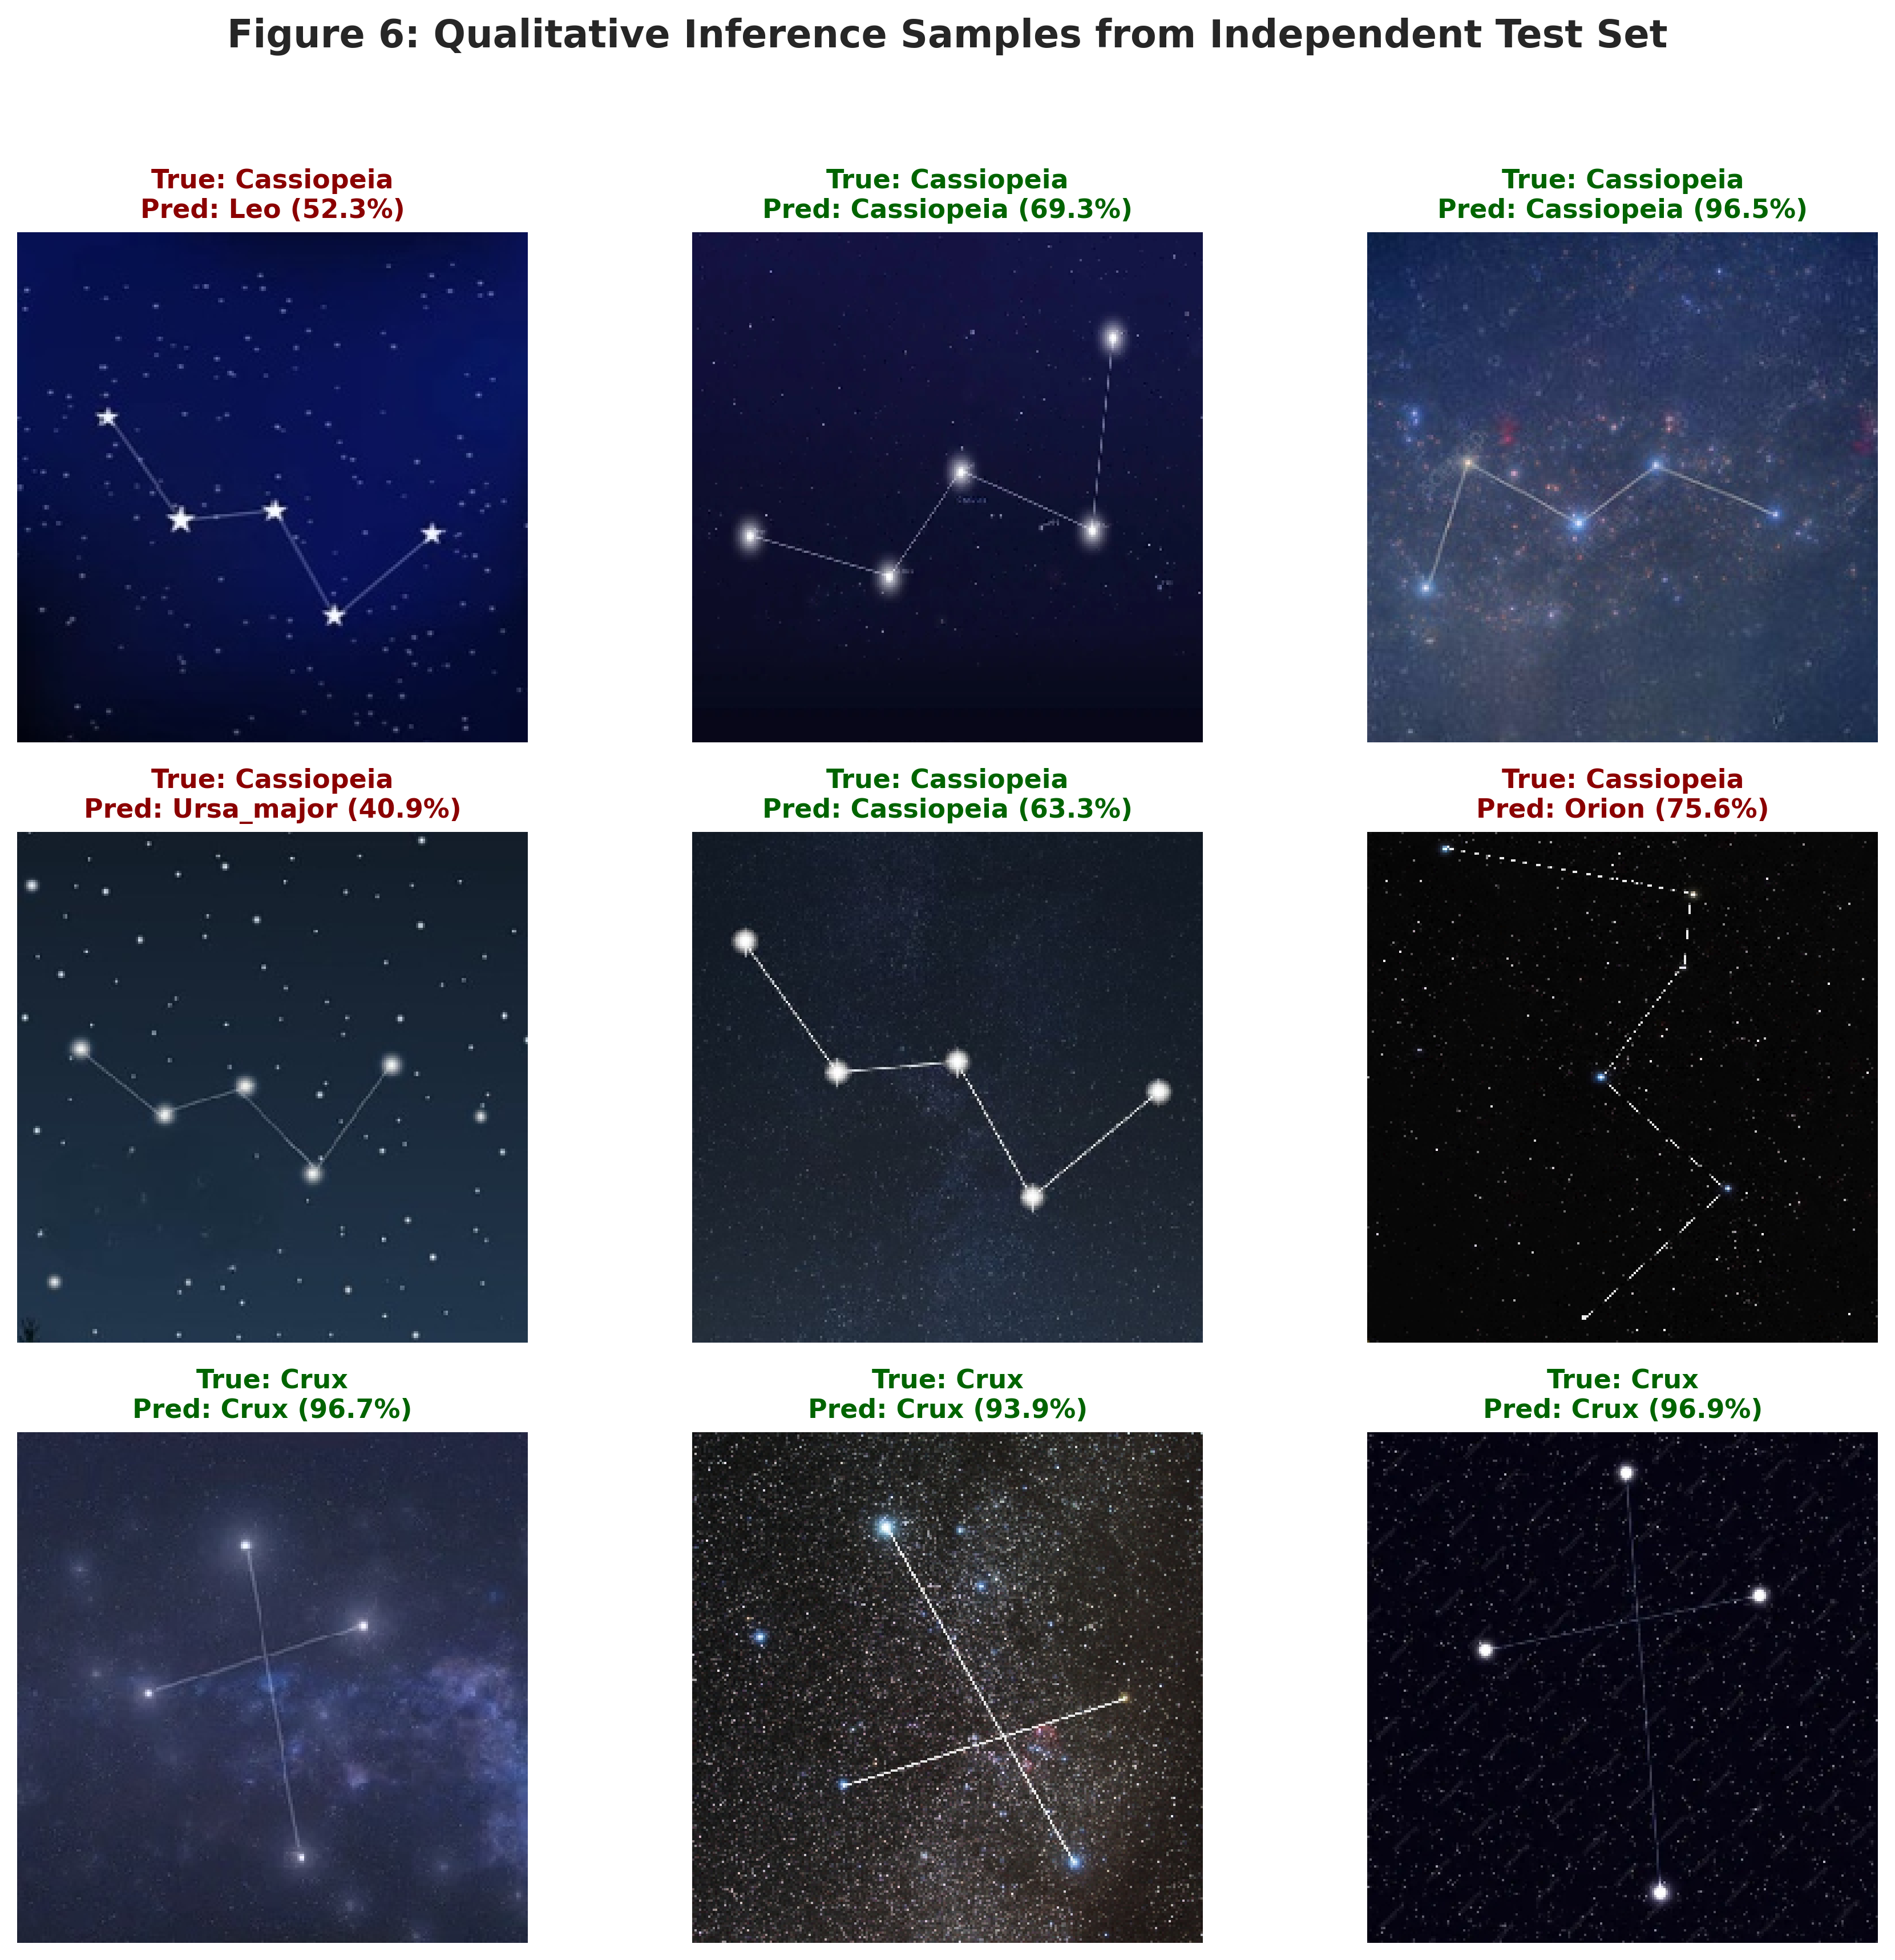

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reset the strictly held-out test generator
final_test_gen.reset()

plt.figure(figsize=(12, 12), dpi=300) # High DPI for paper inclusion

# 2. Loop 9 times to grab 9 individual test images (since batch_size=1)
for i in range(9):
    try:
        images_batch, labels_batch = next(final_test_gen)
    except StopIteration:
        break # Safety catch if your test set has fewer than 9 images

    sample_preds = final_model.predict(images_batch, verbose=0)

    plt.subplot(3, 3, i + 1)
    # The image is the first (and only) item in the batch
    plt.imshow(images_batch[0])

    true_idx = np.argmax(labels_batch[0])
    pred_idx = np.argmax(sample_preds[0])
    conf     = sample_preds[0][pred_idx] * 100

    # Use darker colors for better contrast in print/PDF
    color    = 'darkgreen' if true_idx == pred_idx else 'darkred'

    plt.title(f"True: {class_names[true_idx].capitalize()}\nPred: {class_names[pred_idx].capitalize()} ({conf:.1f}%)",
              color=color, fontweight='bold', fontsize=11)
    plt.axis('off')

plt.suptitle('Figure 6: Qualitative Inference Samples from Independent Test Set',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## ⭐ Final Evaluation on Held-Out Test Set

This is the **only** time the test set is used. The model has never seen
these images during training or hyperparameter tuning.

This is the number that goes into the conference paper.


PHASE 4: FINAL HELD-OUT TEST SET EVALUATION
This cell simulates real-world deployment on unseen data.
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

  Test Accuracy  : 0.6053  (60.53%)
  Correct        : 23/38


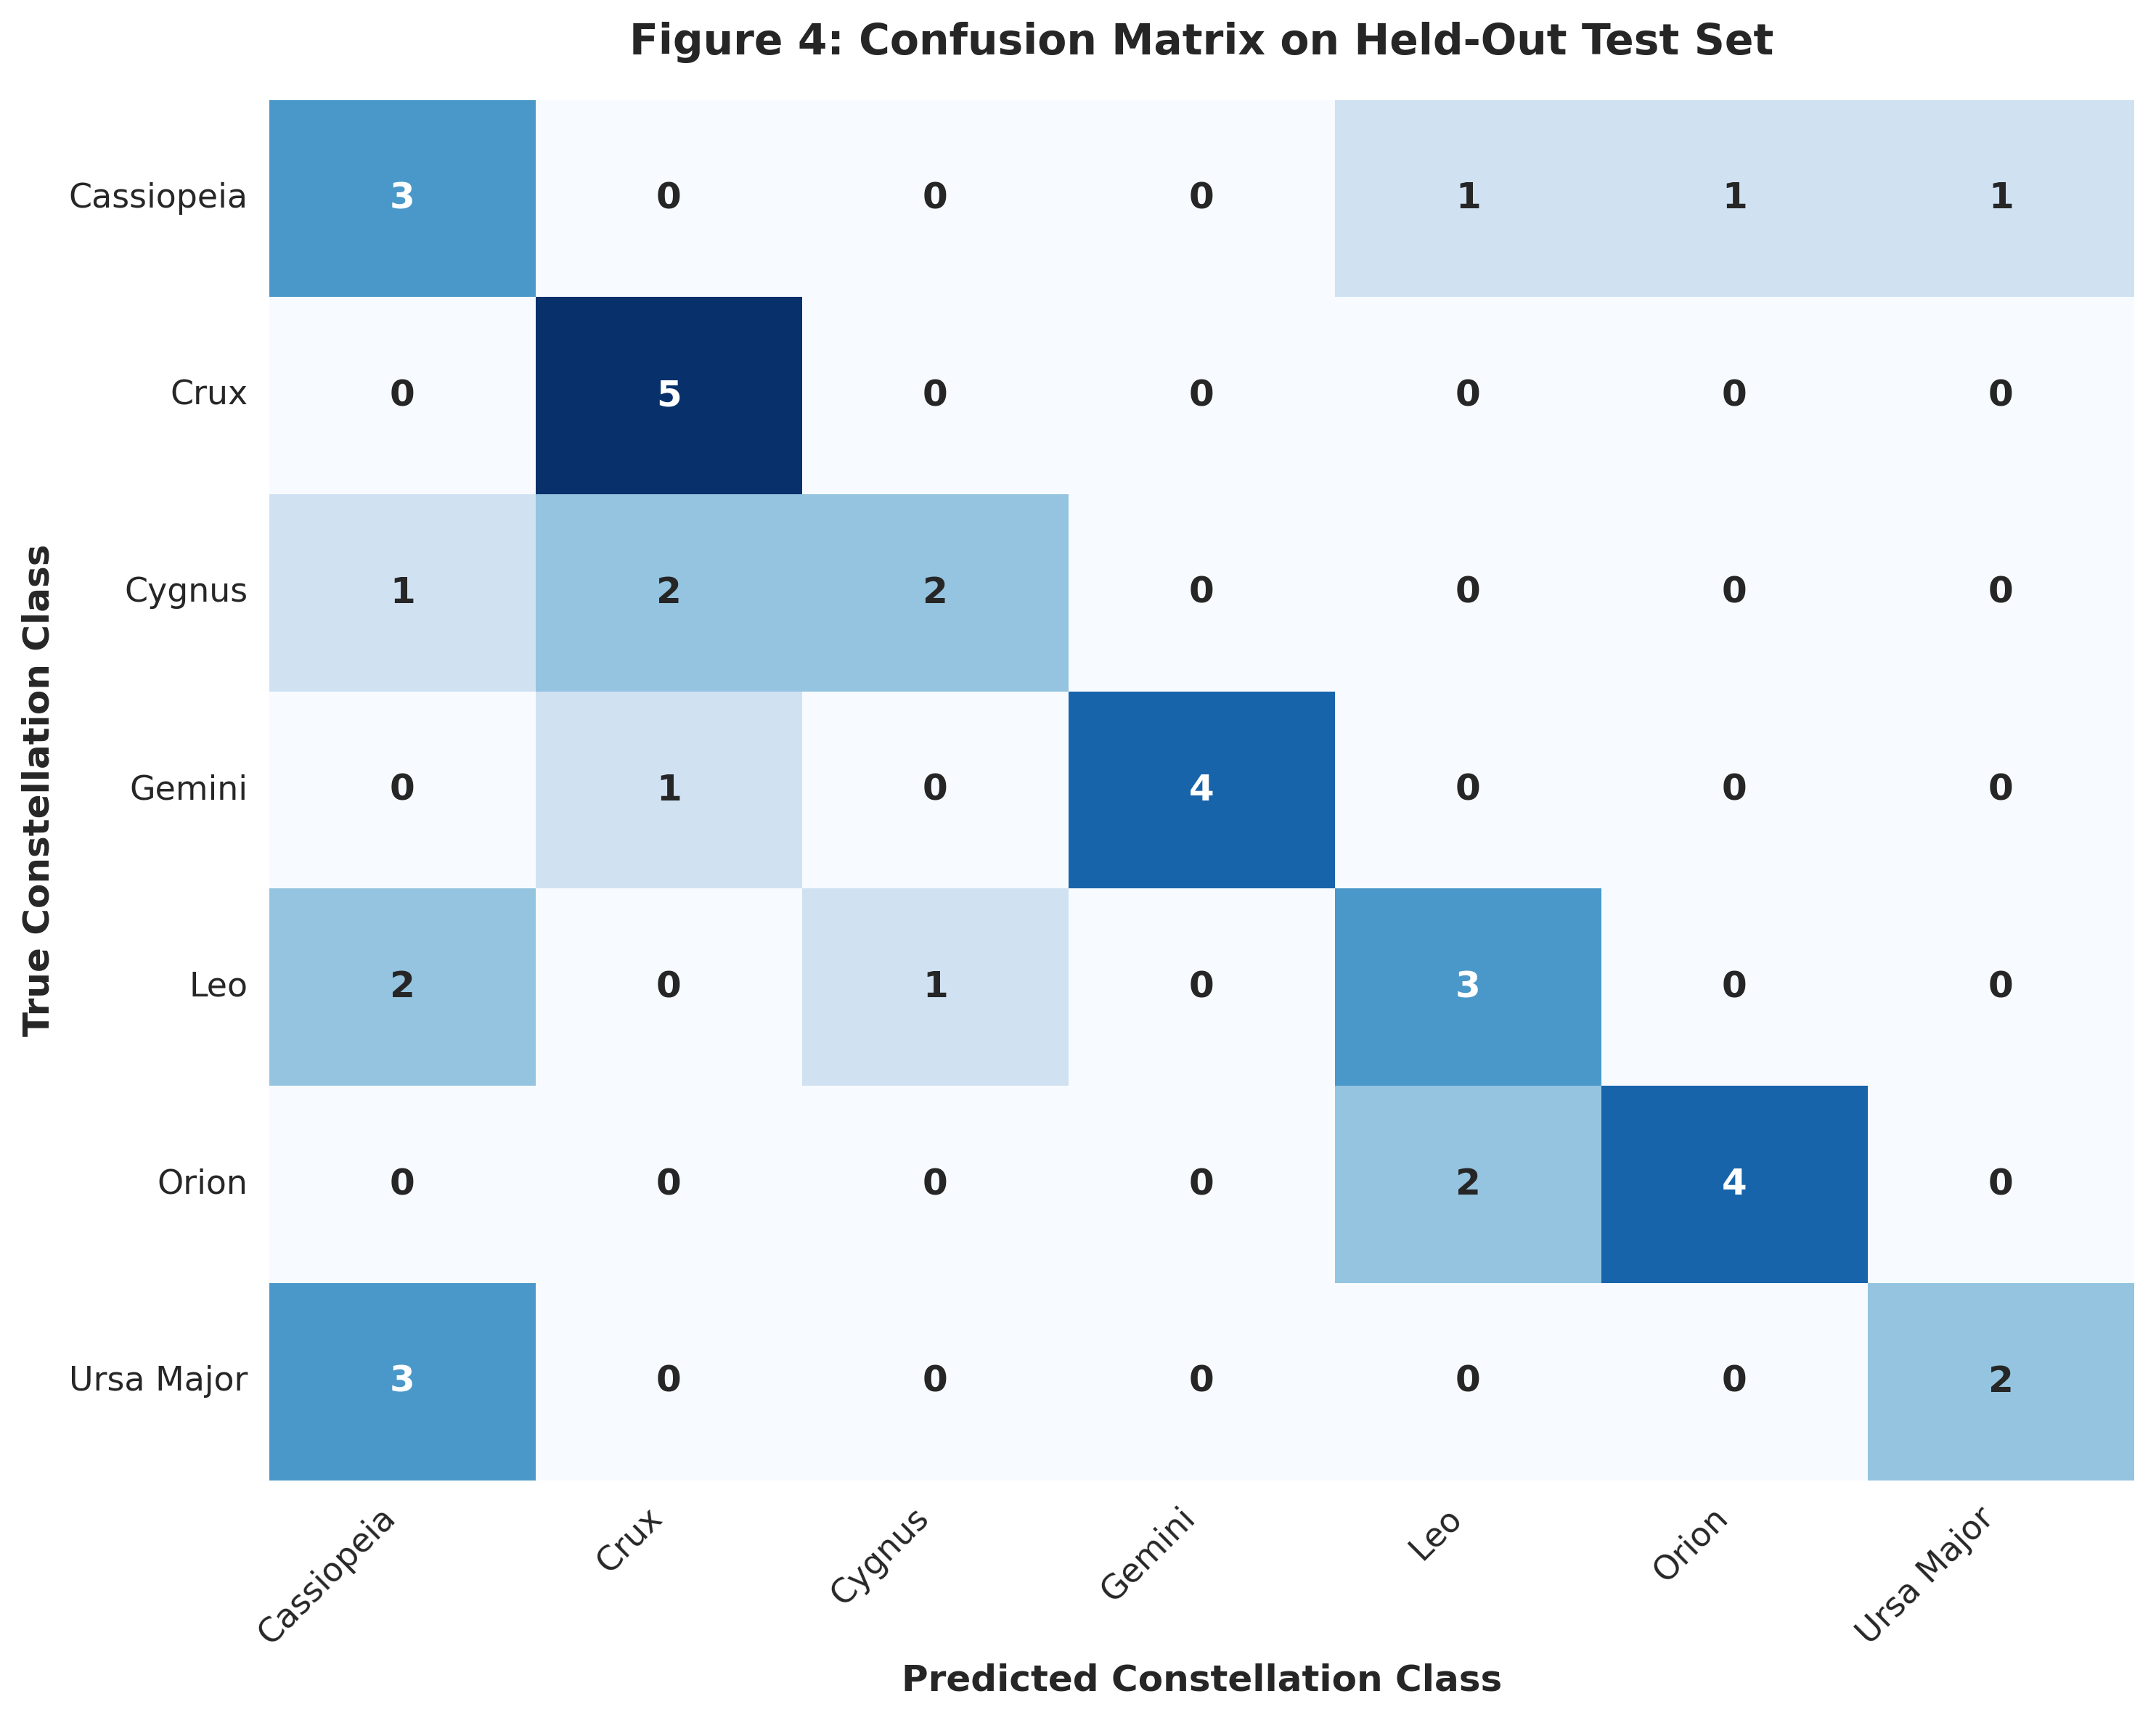

✓ Confusion matrix saved to /content/drive/MyDrive/models/confusion_matrix_test.pdf

Detailed Classification Report — Test Set
              precision    recall  f1-score   support

  Cassiopeia       0.33      0.50      0.40         6
        Crux       0.62      1.00      0.77         5
      Cygnus       0.67      0.40      0.50         5
      Gemini       1.00      0.80      0.89         5
         Leo       0.50      0.50      0.50         6
       Orion       0.80      0.67      0.73         6
  Ursa Major       0.67      0.40      0.50         5

    accuracy                           0.61        38
   macro avg       0.66      0.61      0.61        38
weighted avg       0.65      0.61      0.61        38


--- Paper-Ready Headline Metrics ---
  Architecture | MobileNetV2 (Transfer Learning)
  Test Acc     | 0.6053
  Macro F1     | 0.6122
  Macro Prec   | 0.6560
  Macro Recall | 0.6095
------------------------------------
✓ Numerical test results saved to /content/drive/MyDrive

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
import numpy as np

print("=" * 65)
print("PHASE 4: FINAL HELD-OUT TEST SET EVALUATION")
print("This cell simulates real-world deployment on unseen data.")
print("=" * 65)

# 1. Predictions
test_generator.reset() # Crucial: ensures we start from the first image
test_preds_probs = final_model.predict(test_generator, verbose=1)
test_preds = np.argmax(test_preds_probs, axis=1)
test_true  = test_generator.classes

test_acc = np.mean(test_preds == test_true)

print(f"\n{'='*65}")
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc:.2%})")
print(f"  Correct        : {np.sum(test_preds == test_true)}/{len(test_true)}")
print(f"{'='*65}")

# Clean up class names for the paper (e.g., 'ursa_major' -> 'Ursa Major')
clean_class_names = [c.replace('_', ' ').title() for c in class_names]

# 2. Publication-Quality Confusion Matrix
plt.figure(figsize=(10, 8), dpi=300) # 300 DPI for conference standards
cm_test = confusion_matrix(test_true, test_preds)

# Using 'Blues' is generally safer for grayscale printing than 'Greens'
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=clean_class_names, yticklabels=clean_class_names,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Figure 4: Confusion Matrix on Held-Out Test Set', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Constellation Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Constellation Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save the figure to disk for your paper
cm_path_pdf = os.path.join(MODEL_DIR, 'confusion_matrix_test.pdf')
cm_path_png = os.path.join(MODEL_DIR, 'confusion_matrix_test.png')
plt.savefig(cm_path_pdf, bbox_inches='tight')
plt.savefig(cm_path_png, bbox_inches='tight', dpi=300)
plt.show()
print(f"✓ Confusion matrix saved to {cm_path_pdf}")

# 3. Full classification report
print(f"\n{'='*65}")
print("Detailed Classification Report — Test Set")
print(f"{'='*65}")
test_report = classification_report(test_true, test_preds,
                                     target_names=clean_class_names, output_dict=True)
print(classification_report(test_true, test_preds, target_names=clean_class_names))

# 4. Summary table for paper
print("\n--- Paper-Ready Headline Metrics ---")
print(f"  Architecture | MobileNetV2 (Transfer Learning)")
print(f"  Test Acc     | {test_acc:.4f}")
print(f"  Macro F1     | {test_report['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec   | {test_report['macro avg']['precision']:.4f}")
print(f"  Macro Recall | {test_report['macro avg']['recall']:.4f}")
print("------------------------------------")

# 5. Save test results for later reference
test_results = {
    'test_accuracy': float(test_acc),
    'macro_f1': float(test_report['macro avg']['f1-score']),
    'macro_precision': float(test_report['macro avg']['precision']),
    'macro_recall': float(test_report['macro avg']['recall']),
    'per_class': {
        cls: {
            'precision': float(test_report[cls]['precision']),
            'recall': float(test_report[cls]['recall']),
            'f1-score': float(test_report[cls]['f1-score']),
        }
        for cls in clean_class_names
    }
}
with open(os.path.join(MODEL_DIR, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"✓ Numerical test results saved to {os.path.join(MODEL_DIR, 'test_results.json')}")

## Baseline CNN — Final Comparison

Train the baseline CNN once (same seed, same train/val split) and evaluate
on the test set so we can report a direct comparison in the paper.


PHASE 5: BASELINE COMPARISON & FINAL BENCHMARK
Found 147 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
  >>> Training Baseline CNN for final comparison...

Table 2: Final Model Comparison — Held-Out Test Set
Architecture         |   Accuracy |   Macro F1 | Macro Prec |  Macro Rec
-----------------------------------------------------------------------
Baseline CNN         |     0.2895 |     0.2539 |     0.2385 |     0.3000
MobileNetV2 (Ours)   |     0.6053 |     0.6122 |     0.6560 |     0.6095

Net Improvement (MobileNetV2 over Baseline):
  Accuracy : +31.58 percentage points
  Macro F1 : +35.83 percentage points



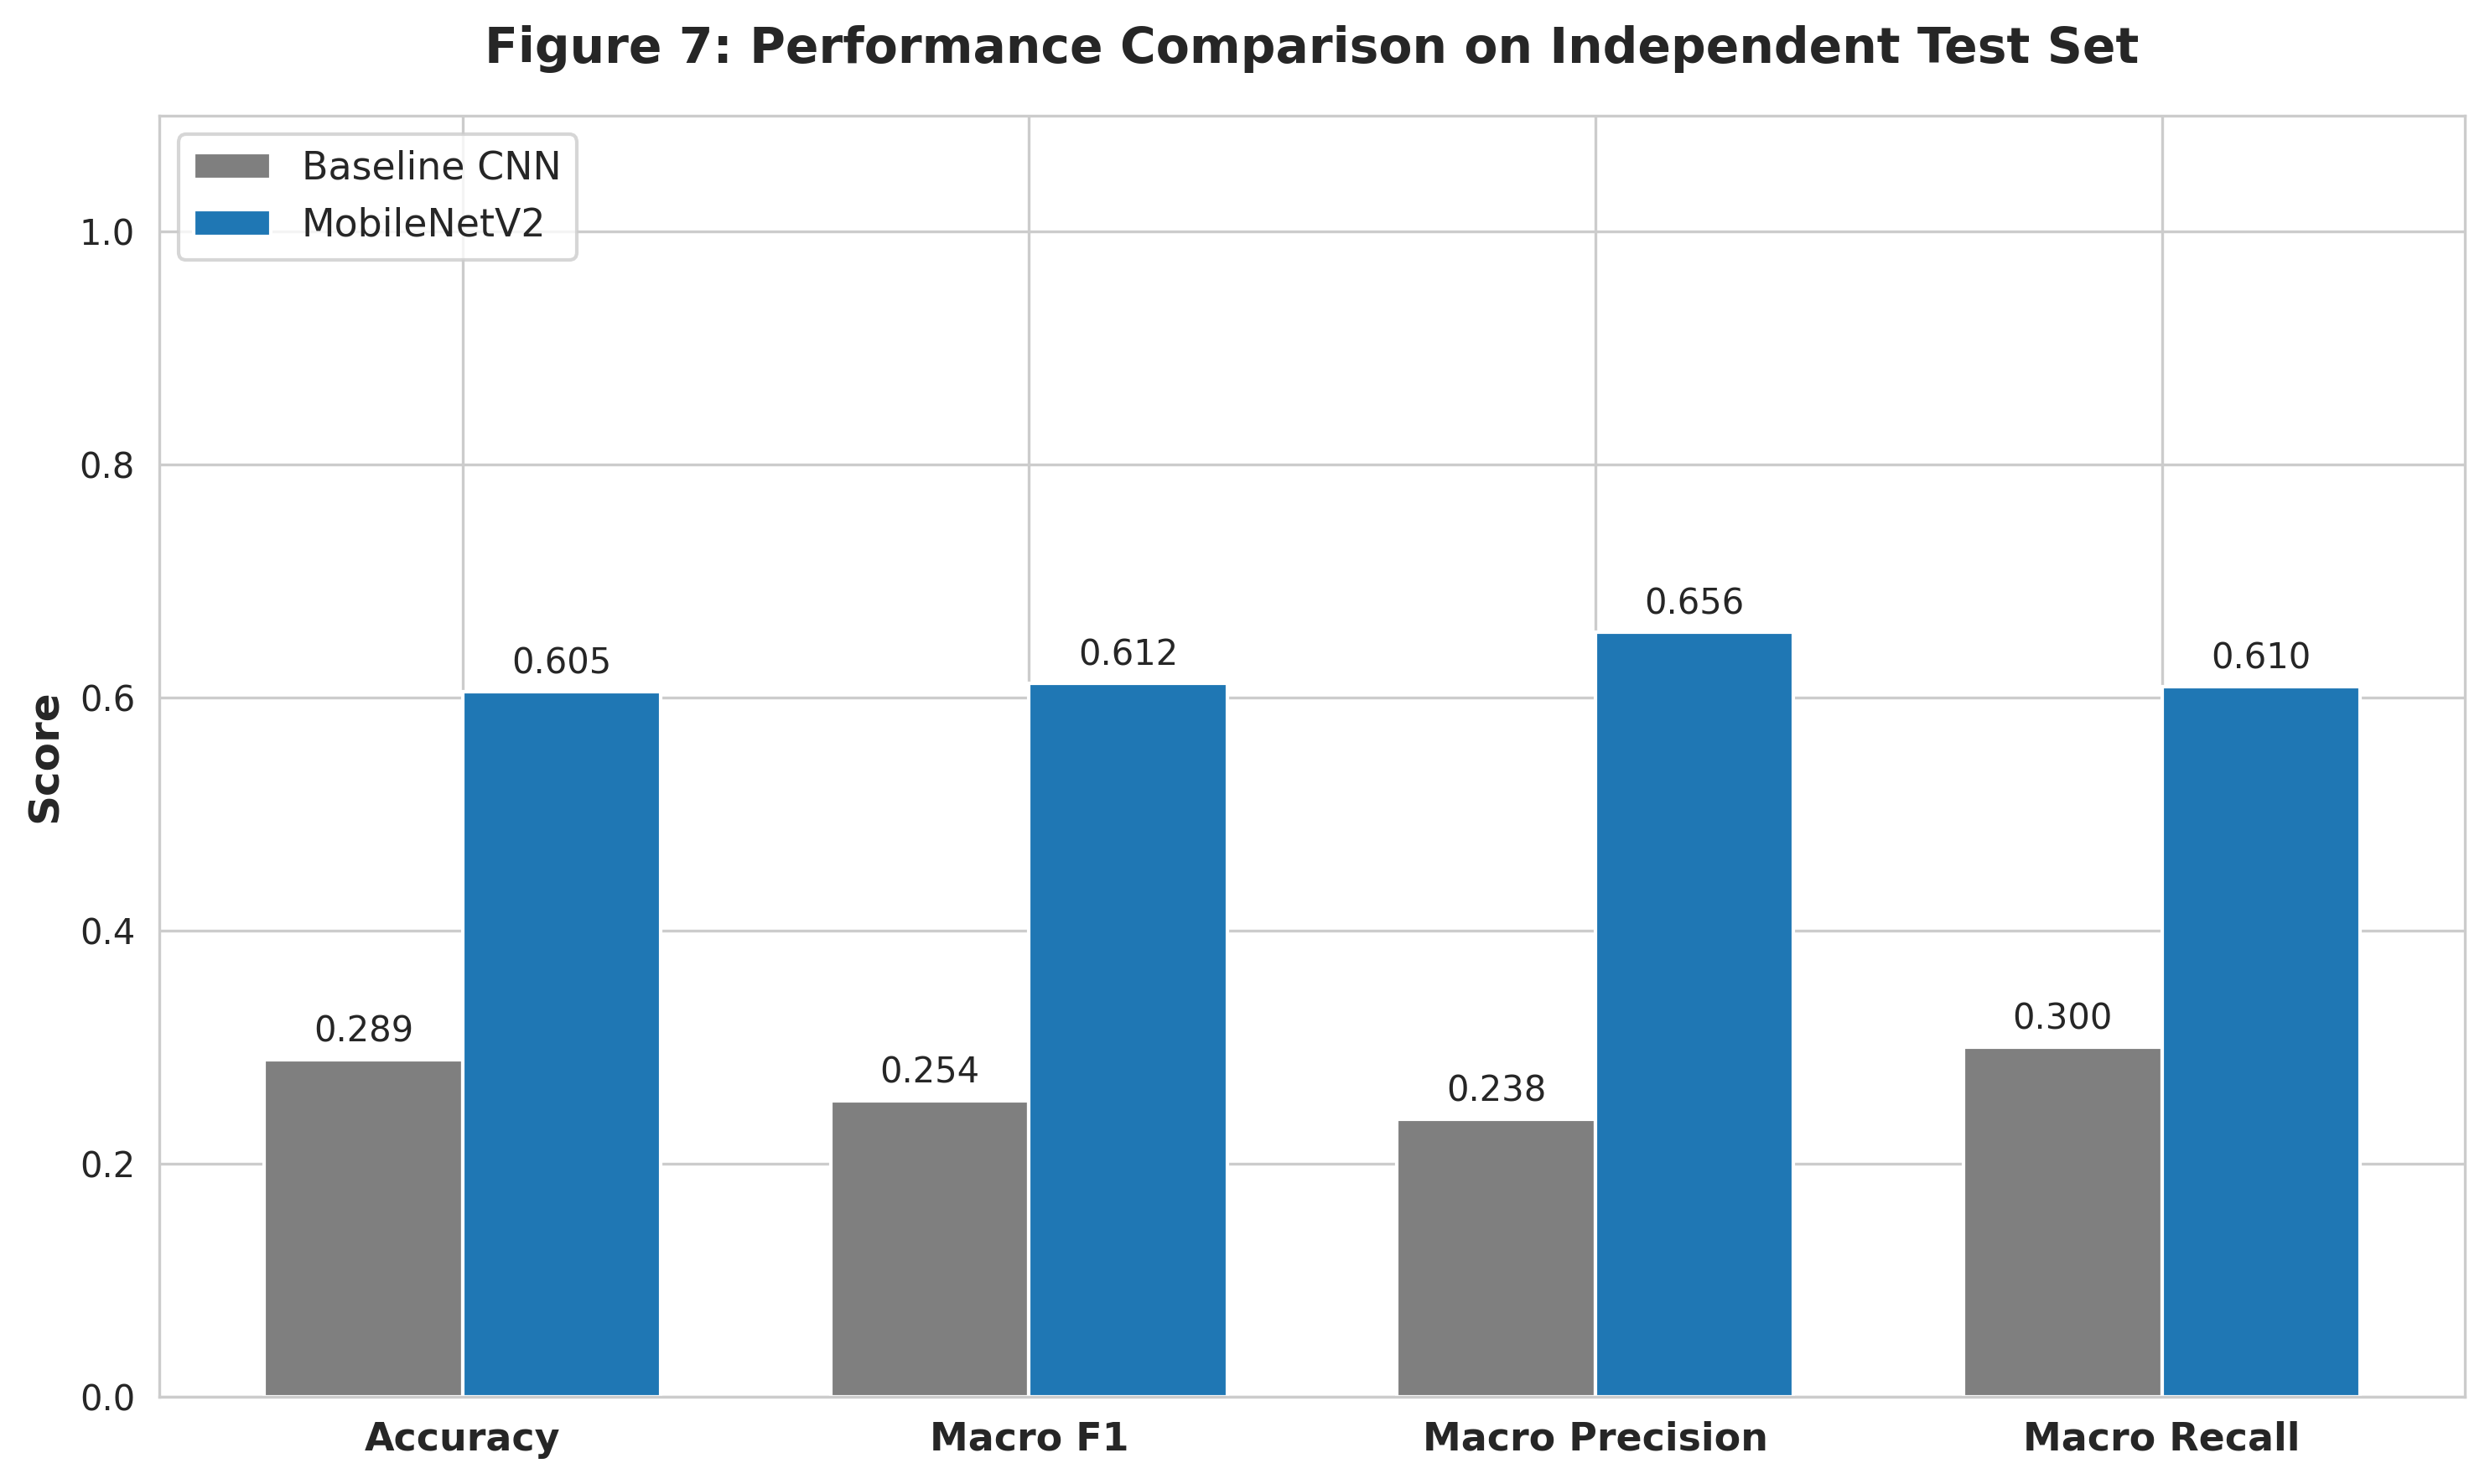

✓ Baseline results and comparison chart saved to /content/drive/MyDrive/models


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from sklearn.metrics import classification_report

print("=" * 65)
print("PHASE 5: BASELINE COMPARISON & FINAL BENCHMARK")
print("=" * 65)

# Ensure reproducibility for the baseline
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Define data generators for baseline model training and validation
baseline_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=RANDOM_SEED
)
baseline_val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1, class_mode='categorical',
    shuffle=False
)

baseline_model = create_baseline_cnn(num_classes, LEARNING_RATE)

cw_b = compute_class_weight(
    'balanced',
    classes=np.unique(baseline_train_gen.classes),
    y=baseline_train_gen.classes
)

print("  >>> Training Baseline CNN for final comparison...")
baseline_model.fit(
    baseline_train_gen,
    epochs=EPOCHS,
    validation_data=baseline_val_gen,
    class_weight=dict(enumerate(cw_b)),
    callbacks=get_callbacks(),
    verbose=0
)

# 1. Evaluate on test set
test_generator.reset() # Crucial reset
baseline_preds = np.argmax(baseline_model.predict(test_generator, verbose=0), axis=1)
baseline_true  = test_generator.classes
baseline_acc   = np.mean(baseline_preds == baseline_true)

# Clean names for report
clean_class_names = [c.replace('_', ' ').title() for c in class_names]

baseline_report = classification_report(baseline_true, baseline_preds,
                                         target_names=clean_class_names, output_dict=True)

# 2. Print Academic Table
print("\n" + "="*65)
print("Table 2: Final Model Comparison — Held-Out Test Set")
print("="*65)
print(f"{'Architecture':<20} | {'Accuracy':>10} | {'Macro F1':>10} | {'Macro Prec':>10} | {'Macro Rec':>10}")
print("-" * 71)
print(f"{'Baseline CNN':<20} | {baseline_acc:>10.4f} | "
      f"{baseline_report['macro avg']['f1-score']:>10.4f} | "
      f"{baseline_report['macro avg']['precision']:>10.4f} | "
      f"{baseline_report['macro avg']['recall']:>10.4f}")
print(f"{'MobileNetV2 (Ours)':<20} | {test_results['test_accuracy']:>10.4f} | "
      f"{test_results['macro_f1']:>10.4f} | "
      f"{test_results['macro_precision']:>10.4f} | "
      f"{test_results['macro_recall']:>10.4f}")
print("="*65)

# 3. Calculate and print improvements
acc_diff = (test_results['test_accuracy'] - baseline_acc) * 100
f1_diff  = (test_results['macro_f1'] - baseline_report['macro avg']['f1-score']) * 100

print(f"\nNet Improvement (MobileNetV2 over Baseline):")
print(f"  Accuracy : +{acc_diff:.2f} percentage points")
print(f"  Macro F1 : +{f1_diff:.2f} percentage points\n")

# 4. Generate Publication-Quality Bar Chart
metrics = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
baseline_scores = [
    baseline_acc,
    baseline_report['macro avg']['f1-score'],
    baseline_report['macro avg']['precision'],
    baseline_report['macro avg']['recall']
]
mobilenet_scores = [
    test_results['test_accuracy'],
    test_results['macro_f1'],
    test_results['macro_precision'],
    test_results['macro_recall']
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline CNN', color='#7f7f7f')
rects2 = ax.bar(x + width/2, mobilenet_scores, width, label='MobileNetV2', color='#1f77b4')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 7: Performance Comparison on Independent Test Set', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend(loc='upper left', fontsize=11)

# Attach a text label above each bar displaying its height
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
comparison_path = os.path.join(MODEL_DIR, 'model_comparison_chart.png')
plt.savefig(comparison_path, bbox_inches='tight', dpi=300)
plt.show()

# 5. Save baseline results
baseline_results = {
    'test_accuracy': float(baseline_acc),
    'macro_f1': float(baseline_report['macro avg']['f1-score']),
    'macro_precision': float(baseline_report['macro avg']['precision']),
    'macro_recall': float(baseline_report['macro avg']['recall']),
}
with open(os.path.join(MODEL_DIR, 'baseline_results.json'), 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f"✓ Baseline results and comparison chart saved to {MODEL_DIR}")

## Complete Results Summary — Paper-Ready Numbers

In [ ]:
print("=" * 65)
print("COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER")
print("=" * 65)

# CV results
for arch, res in cv_results.items():
    a = np.array(res['acc'])
    f = np.array(res['f1'])
    print(f"\n{arch} — 5-Fold Cross-Validation (train+val pool):")
    print(f"  Accuracy : {a.mean():.4f} ± {a.std():.4f}  "
          f"[95% CI: {a.mean()-1.96*a.std():.4f}–{a.mean()+1.96*a.std():.4f}]")
    print(f"  Macro F1 : {f.mean():.4f} ± {f.std():.4f}")

# Multi-seed
ma = np.array(seed_results['acc'])
mf = np.array(seed_results['f1'])
print(f"\nMobileNetV2 — Multi-Seed Runs ({N_SEEDS} seeds, val set):")
print(f"  Accuracy : {ma.mean():.4f} ± {ma.std():.4f}")
print(f"  Macro F1 : {mf.mean():.4f} ± {mf.std():.4f}")

# Final test
print(f"\nFinal Test Set Evaluation (one-time, held-out):")
print(f"  MobileNetV2  Accuracy  : {test_results['test_accuracy']:.4f}")
print(f"  MobileNetV2  Macro F1  : {test_results['macro_f1']:.4f}")
print(f"  Baseline CNN Accuracy  : {baseline_results['test_accuracy']:.4f}")
print(f"  Baseline CNN Macro F1  : {baseline_results['macro_f1']:.4f}")
print(f"  Transfer learning gain : +{(test_results['test_accuracy']-baseline_results['test_accuracy'])*100:.2f} pp accuracy")

print("=" * 65)


COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER

MobileNetV2 — 5-Fold Cross-Validation (train+val pool):
  Accuracy : 0.5829 ± 0.1123  [95% CI: 0.3628–0.8029]
  Macro F1 : 0.5660 ± 0.1162

Baseline CNN — 5-Fold Cross-Validation (train+val pool):
  Accuracy : 0.1771 ± 0.0379  [95% CI: 0.1029–0.2514]
  Macro F1 : 0.0891 ± 0.0242

MobileNetV2 — Multi-Seed Runs (5 seeds, val set):
  Accuracy : 0.5643 ± 0.0474
  Macro F1 : 0.5640 ± 0.0484

Final Test Set Evaluation (one-time, held-out):
  MobileNetV2  Accuracy  : 0.6053
  MobileNetV2  Macro F1  : 0.6122
  Baseline CNN Accuracy  : 0.2895
  Baseline CNN Macro F1  : 0.2539
  Transfer learning gain : +31.58 pp accuracy


## Save Final Model

In [ ]:
os.makedirs(MODEL_DIR, exist_ok=True)

model_path   = os.path.join(MODEL_DIR, "constellation_classifier.keras")
classes_path = os.path.join(MODEL_DIR, "classes.json")

final_model.save(model_path)
with open(classes_path, 'w') as f:
    json.dump(class_names, f)

print(f"✓ Model  saved → {model_path}")
print(f"✓ Classes saved → {classes_path}")
print()
print("To reload:")
print("  model = keras.models.load_model(model_path)")
print("  with open(classes_path) as f: class_names = json.load(f)")


✓ Model  saved → /content/drive/MyDrive/models/constellation_classifier.keras
✓ Classes saved → /content/drive/MyDrive/models/classes.json

To reload:
  model = keras.models.load_model(model_path)
  with open(classes_path) as f: class_names = json.load(f)


## Grad-CAM

PHASE 6: MODEL EXPLAINABILITY (GRAD-CAM)


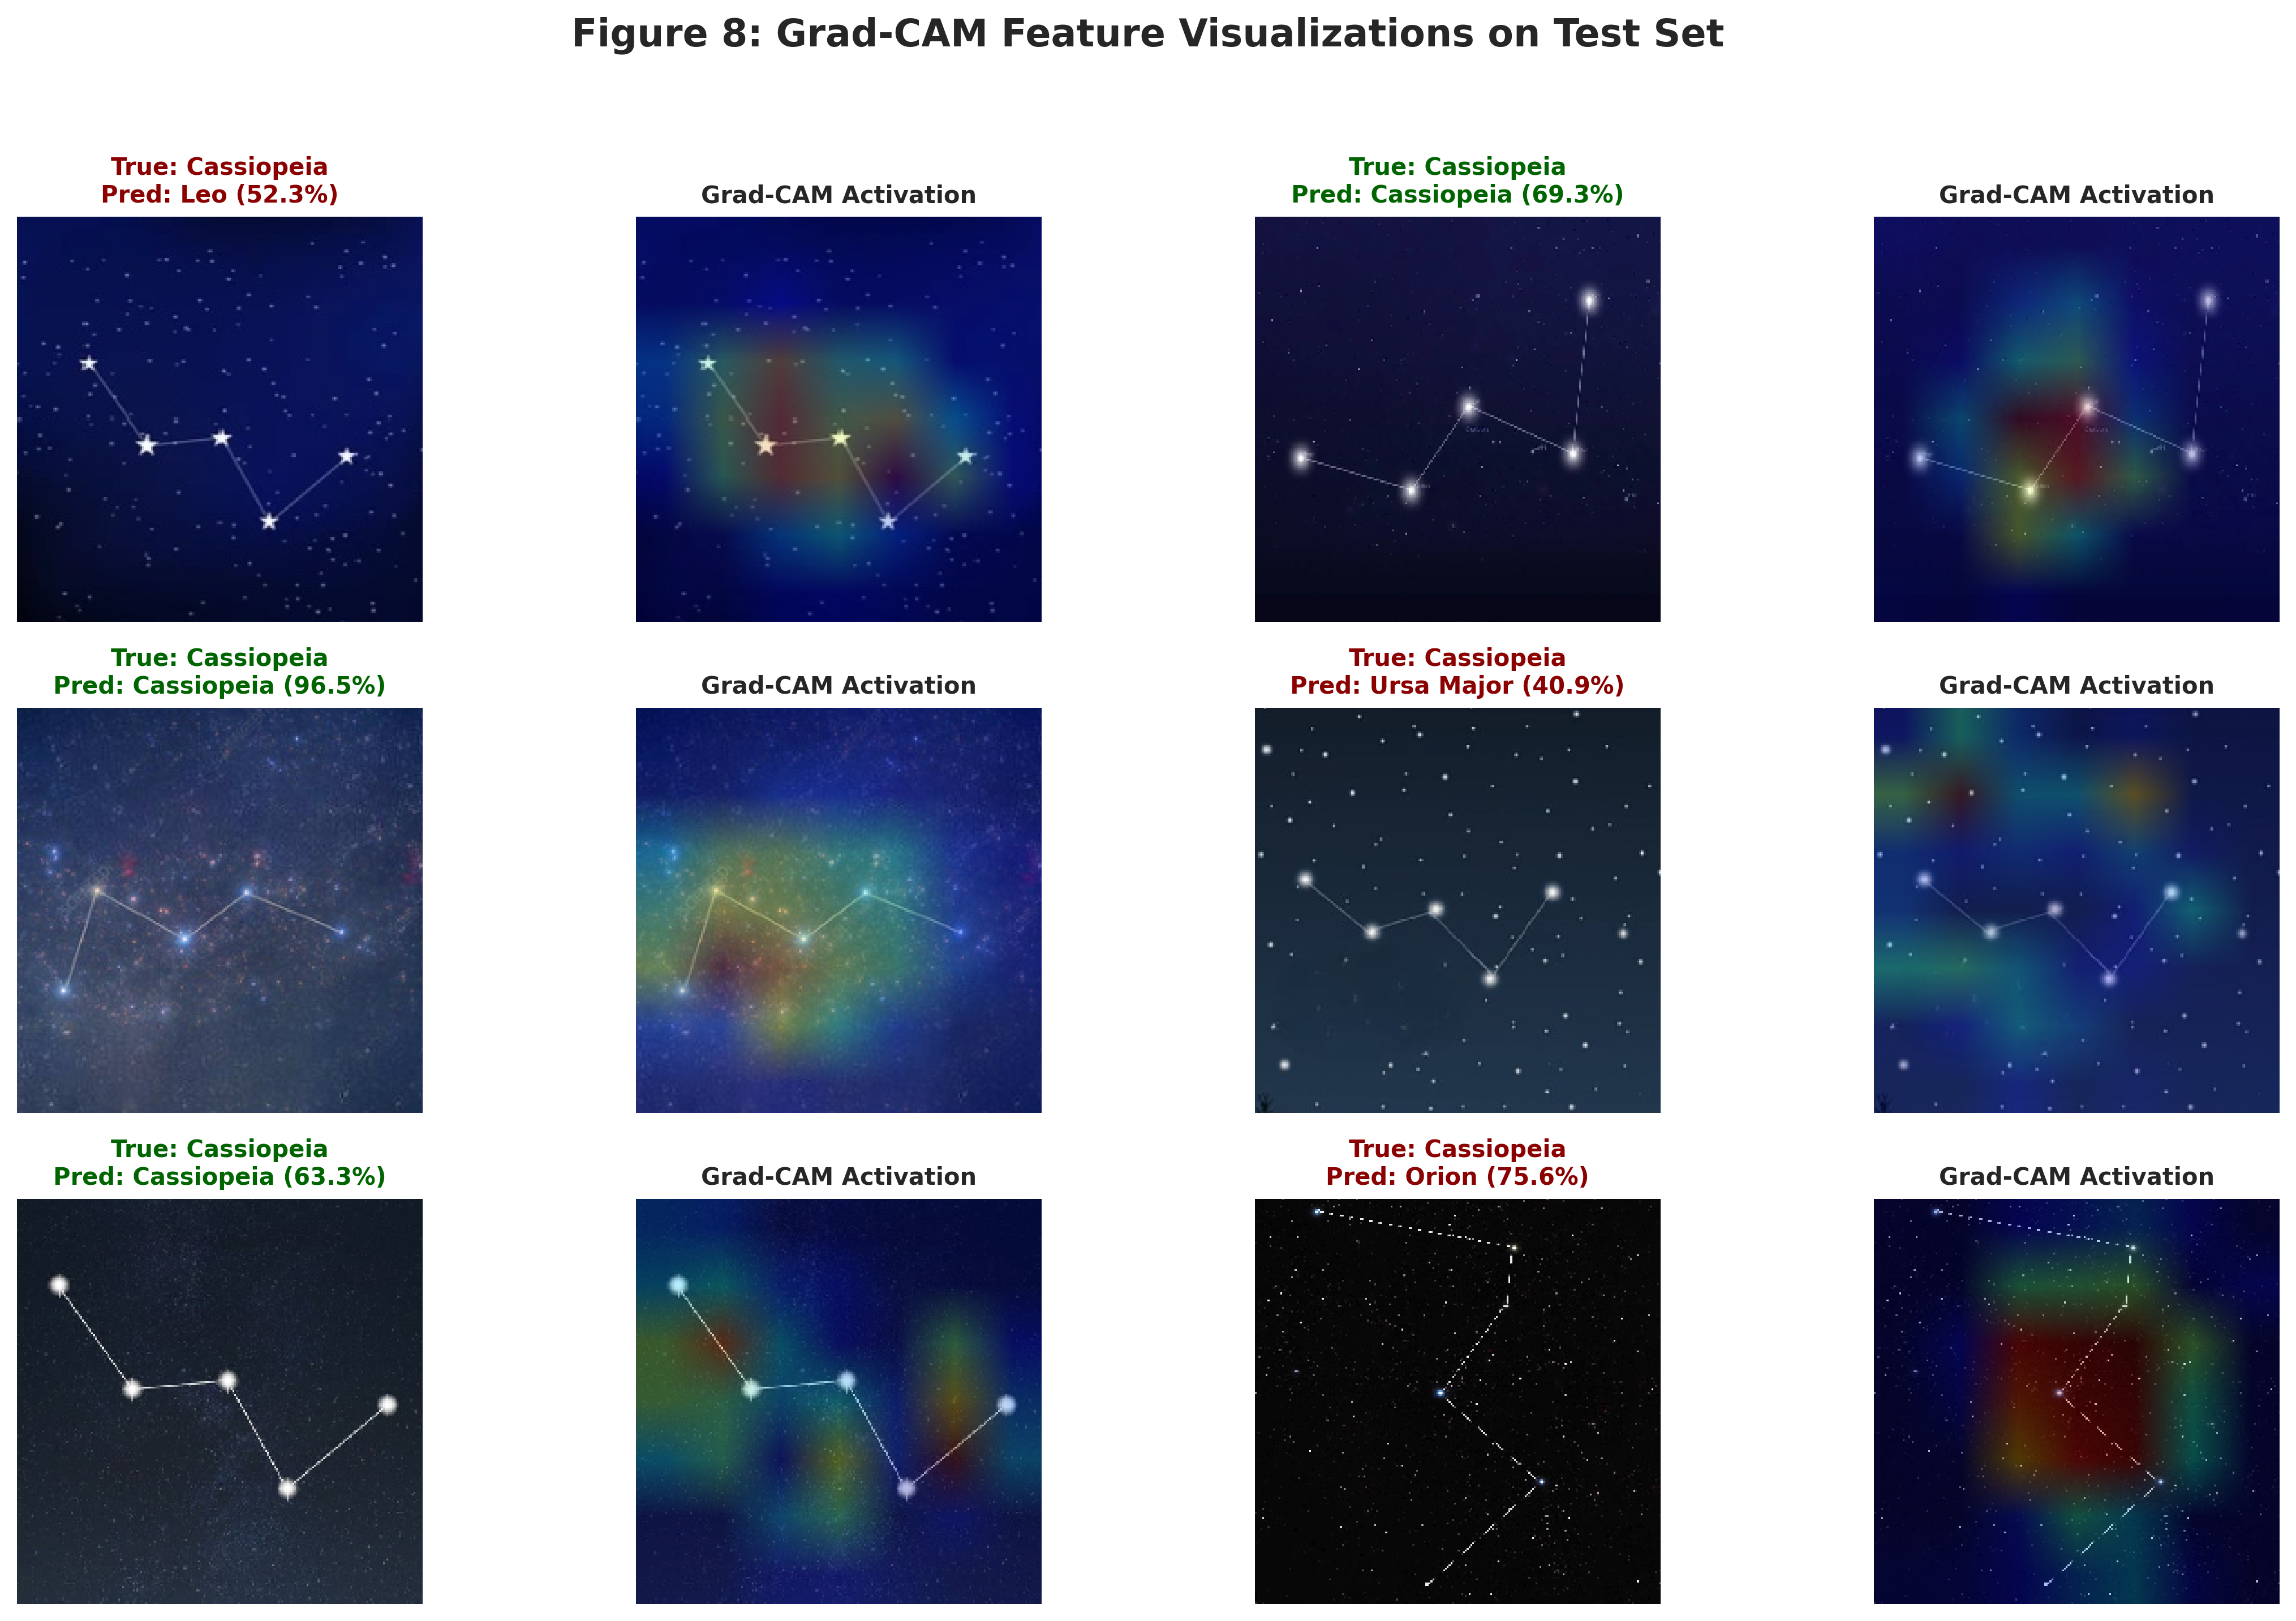

✓ Grad-CAM visualizations saved to /content/drive/MyDrive/models/gradcam_visualizations.png


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("=" * 65)
print("PHASE 6: MODEL EXPLAINABILITY (GRAD-CAM)")
print("=" * 65)

def get_gradcam_heatmap(img_array, model, last_conv_layer_name="out_relu", pred_index=None):
    """
    Generates a Grad-CAM heatmap specifically handling nested transfer learning models.
    """
    # 1. Extract the base MobileNetV2 model (which is the first layer of your model)
    base_model = model.layers[0]

    # 2. Create a sub-model that maps the input image to the last convolutional layer
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    conv_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)

    # 3. Create a sub-model that maps the conv layer to the final prediction
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Apply all the remaining layers from your final_model (GAP, Dense, Dropout, etc.)
    for layer in model.layers[1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    # 4. Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Get the feature maps from the base model
        last_conv_output = conv_model(img_array)
        tape.watch(last_conv_output) # Crucial: tell the tape to track these features

        # Get the final predictions from the classifier model
        preds = classifier_model(last_conv_output)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Calculate gradients of the predicted class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_output)

    # 6. Average the gradients spatially
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Multiply feature map channels by their gradient importance
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    """
    Overlays the heatmap onto the original image.
    """
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    return superimposed_img

# --- EXECUTION ON TEST SET ---
# Reset test generator to grab a fresh batch
test_generator.reset()

plt.figure(figsize=(15, 10), dpi=300)

for i in range(6):
    try:
        img_batch, label_batch = next(test_generator)
    except StopIteration:
        break

    img_array = img_batch[0]
    true_label = class_names[np.argmax(label_batch[0])].replace('_', ' ').title()

    img_tensor = np.expand_dims(img_array, axis=0)

    preds = final_model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_label = class_names[pred_idx].replace('_', ' ').title()
    conf = preds[0][pred_idx] * 100

    # We default to 'out_relu', which is standard for MobileNetV2
    heatmap = get_gradcam_heatmap(img_tensor, final_model, "out_relu")
    cam_image = display_gradcam(img_array, heatmap)

    # Plot Original Image
    plt.subplot(3, 4, 2*i + 1)
    plt.imshow(img_array)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
              fontsize=10, fontweight='bold',
              color='darkgreen' if true_label == pred_label else 'darkred')
    plt.axis('off')

    # Plot Grad-CAM Overlay
    plt.subplot(3, 4, 2*i + 2)
    plt.imshow(cam_image)
    plt.title("Grad-CAM Activation", fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle('Figure 8: Grad-CAM Feature Visualizations on Test Set', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
cam_path = os.path.join(MODEL_DIR, 'gradcam_visualizations.png')
plt.savefig(cam_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"✓ Grad-CAM visualizations saved to {cam_path}")